# BIRD MiniDev500: Gold-Aware Base vs SFT Failure Mode Analysis v3

This notebook is the audited v3 analysis for the two **with-evidence** conditions only:

- `baseline_with_evidence`
- `sft_with_evidence`

It retains the v2 SQL-AST rule engine, incorporates the completed 116-row adjudication workbook, excludes known benchmark/reference issues from model-error summaries, evaluates an audit-calibrated reranker without leakage, and applies human labels only to rows that were actually audited.

The four-way inference notebook and its no-evidence CSVs remain unchanged for ablation reproducibility.


## 0. Method and interpretation

The pipeline deliberately separates three questions:

1. **Execution result:** did Candidate-1 match the reference execution result?
2. **Adjudication status:** is an execution mismatch a confirmed model error, a semantically equivalent query, a prediction that is better than Gold, an ambiguous benchmark item, or a case requiring database execution?
3. **Failure mode:** for confirmed/provisional model errors, what is the most plausible root cause?

Final manual labels are used for audited rows. Unreviewed rows remain clearly marked as provisional. The stratified audit oversamples difficult cases, so audit agreement is a classifier-validation statistic—not a population accuracy estimate.


## 1. Install dependencies


In [1]:
%pip -q install "pandas==2.2.2" "openpyxl>=3.1,<3.2" "sqlglot>=23.4,<25.21" "scikit-learn>=1.4,<1.7" "seaborn>=0.13" "matplotlib>=3.8"


## 2. Imports and project paths


In [2]:
import hashlib
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sqlglot
from sqlglot import exp
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; using the configured local PROJECT_ROOT.")

SEED = 42
rng = np.random.default_rng(SEED)


Mounted at /content/drive


In [3]:
# ========================= PROJECT LAYOUT =========================
PROJECT_ROOT = Path("/content/drive/MyDrive/bird-text2sql-sft")
RESULTS_ROOT = PROJECT_ROOT / "results"

PREFERRED_RESULTS_DIR = RESULTS_ROOT / "minidev500_ex1_oracle3_oracle5_four_way"
FALLBACK_RESULTS_DIRS = [
    RESULTS_ROOT / "minidev500_four_way_v2",
    RESULTS_ROOT / "minidev500_four_way",
    RESULTS_ROOT / "minidev500_baseline_vs_sft",
]

V2_ANALYSIS_DIR = RESULTS_ROOT / "minidev500_failure_mode_analysis_with_evidence_v2"
OUTPUT_DIR = RESULTS_ROOT / "minidev500_failure_mode_analysis_with_evidence_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set this to a Path if the completed workbook is stored elsewhere.
ADJUDICATION_FILE_OVERRIDE = None
EXPECTED_AUDIT_ROWS = 116
REQUIRE_COMPLETE_ADJUDICATION = True

CANDIDATE_RANK = 1
CLASSIFIER_V3_VERSION = "3.0-gold-aware"
CV_SPLITS = 2  # smallest audited failure classes contain only two rows
MIN_DEPLOY_GAIN = 0.01

print("Project root:", PROJECT_ROOT)
print("Preferred result directory:", PREFERRED_RESULTS_DIR)
print("v3 output directory:", OUTPUT_DIR)
# ==================================================================


Project root: /content/drive/MyDrive/bird-text2sql-sft
Preferred result directory: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_ex1_oracle3_oracle5_four_way
v3 output directory: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_failure_mode_analysis_with_evidence_v3


## 3. Locate and validate the two with-evidence inference CSVs

Both files must come from the same inference directory. No-evidence artifacts are intentionally ignored here.


In [4]:
EXPECTED_RESULT_FILES = (
    "baseline_with_evidence_minidev500_results.csv",
    "sft_with_evidence_minidev500_results.csv",
)


def bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.fillna(False).astype(str).str.strip().str.lower().isin(
        {"true", "1", "yes", "y"}
    )


def expected_result_files(directory):
    directory = Path(directory)
    files = [directory / filename for filename in EXPECTED_RESULT_FILES]
    return files if all(path.is_file() for path in files) else []


def choose_results_directory():
    ordered = [PREFERRED_RESULTS_DIR, *FALLBACK_RESULTS_DIRS]
    seen = set()

    for directory in ordered:
        resolved = str(directory)
        if resolved in seen:
            continue
        seen.add(resolved)
        files = expected_result_files(directory)
        if files:
            return directory, files

    # Last-resort recursive discovery, grouped by parent directory.
    if RESULTS_ROOT.exists():
        by_parent = {}
        for path in RESULTS_ROOT.rglob(EXPECTED_RESULT_FILES[0]):
            by_parent.setdefault(path.parent, expected_result_files(path.parent))
        complete = [(parent, files) for parent, files in by_parent.items() if files]
        if complete:
            complete.sort(key=lambda item: str(item[0]))
            return complete[0]

    searched = [str(path) for path in ordered]
    raise FileNotFoundError(
        "Could not find the aligned with-evidence Base and SFT CSVs. Searched:\n- "
        + "\n- ".join(searched)
        + "\nRequired filenames: " + ", ".join(EXPECTED_RESULT_FILES)
        + "\nRun the inference notebook first or update PREFERRED_RESULTS_DIR."
    )


SELECTED_RESULTS_DIR, RESULT_FILES = choose_results_directory()
print("Selected result directory:", SELECTED_RESULTS_DIR)
print("With-evidence result CSVs selected for analysis:")
for path in RESULT_FILES:
    print(" -", path.name)

Selected result directory: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_ex1_oracle3_oracle5_four_way
With-evidence result CSVs selected for analysis:
 - baseline_with_evidence_minidev500_results.csv
 - sft_with_evidence_minidev500_results.csv


In [5]:
def infer_model_type(path, df):
    if "model_type" in df.columns and df["model_type"].notna().any():
        values = df["model_type"].dropna().astype(str).str.lower().unique()
        if len(values) == 1 and values[0] in {"baseline", "base", "sft"}:
            return "baseline" if values[0] in {"baseline", "base"} else "sft"
    text = path.stem.lower()
    if "sft" in text:
        return "sft"
    if "baseline" in text or re.search(r"(^|[_-])base([_-]|$)", text):
        return "baseline"
    raise ValueError(f"Cannot infer model type from {path.name}")


def choose_column(df, candidates, purpose):
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(f"Missing {purpose}. Tried columns={candidates}")


def normalize_result_frame(path):
    raw = pd.read_csv(path)
    model_type = infer_model_type(path, raw)
    experiment = f"{model_type}_with_evidence"

    if "use_evidence" in raw.columns and raw["use_evidence"].notna().any():
        evidence_flags = bool_series(raw["use_evidence"])
        if not evidence_flags.all():
            raise ValueError(
                f"{path.name} contains rows with use_evidence=False; "
                "this notebook is intentionally evidence-only."
            )

    sql_col = choose_column(
        raw,
        [f"candidate_{CANDIDATE_RANK}_predicted_sql", "predicted_sql"],
        "predicted SQL",
    )
    valid_col = choose_column(
        raw,
        [f"candidate_{CANDIDATE_RANK}_valid_sql", "valid_sql"],
        "SQL validity",
    )
    match_candidates = [f"candidate_{CANDIDATE_RANK}_execution_match"]
    if CANDIDATE_RANK == 1:
        match_candidates += ["ex_at_1", "execution_match"]
    else:
        match_candidates += ["execution_match"]
    match_col = choose_column(raw, match_candidates, "execution correctness")

    required = ["position", "db_id", "gold_sql"]
    missing = [column for column in required if column not in raw.columns]
    if missing:
        raise KeyError(f"{path.name} is missing required columns: {missing}")

    df = raw.copy()
    df["experiment"] = experiment
    df["model_type"] = model_type
    df["use_evidence"] = True
    df["analysis_predicted_sql"] = df[sql_col].fillna("").astype(str)
    df["analysis_valid_sql"] = bool_series(df[valid_col])
    df["analysis_execution_match"] = bool_series(df[match_col])
    df["source_result_file"] = path.name

    if "question" not in df.columns:
        df["question"] = ""
    if "evidence" not in df.columns:
        df["evidence"] = ""
    if "difficulty" not in df.columns:
        df["difficulty"] = "unknown"
    if "source_index" not in df.columns:
        df["source_index"] = df["position"]
    if "pipeline_error" not in df.columns:
        df["pipeline_error"] = ""

    df["position"] = pd.to_numeric(df["position"], errors="raise").astype(int)
    df["pipeline_error"] = df["pipeline_error"].fillna("").astype(str)
    df["gold_sql"] = df["gold_sql"].fillna("").astype(str)

    if df["position"].duplicated().any():
        duplicates = df.loc[df["position"].duplicated(), "position"].tolist()[:10]
        raise ValueError(f"Duplicate positions in {path.name}: {duplicates}")
    return df


frames = [normalize_result_frame(path) for path in RESULT_FILES]
expected_experiments = {"baseline_with_evidence", "sft_with_evidence"}
actual_experiments = {frame["experiment"].iloc[0] for frame in frames}
if actual_experiments != expected_experiments:
    raise RuntimeError(
        f"Expected exactly {sorted(expected_experiments)}, got {sorted(actual_experiments)}."
    )

all_results = pd.concat(frames, ignore_index=True, sort=False)
all_results["analysis_state"] = np.select(
    [
        all_results["pipeline_error"].str.len().gt(0),
        all_results["analysis_execution_match"],
        all_results["analysis_valid_sql"] & ~all_results["analysis_execution_match"],
    ],
    ["pipeline_error", "correct", "valid_wrong"],
    default="invalid_sql",
)

overview = (
    all_results.groupby(["experiment", "model_type", "use_evidence"], as_index=False)
    .agg(
        examples=("position", "size"),
        correct=("analysis_execution_match", "sum"),
        valid_sql=("analysis_valid_sql", "sum"),
        valid_wrong=("analysis_state", lambda s: int((s == "valid_wrong").sum())),
        databases=("db_id", "nunique"),
    )
)
overview["ex_at_1"] = overview["correct"] / overview["examples"]
overview["valid_sql_rate"] = overview["valid_sql"] / overview["examples"]
overview["valid_wrong_rate"] = overview["valid_wrong"] / overview["examples"]

display(overview.style.format({
    "ex_at_1": "{:.2%}",
    "valid_sql_rate": "{:.2%}",
    "valid_wrong_rate": "{:.2%}",
}))

assert set(all_results["use_evidence"].unique()) == {True}

base_keys = set(map(tuple, all_results.loc[
    all_results["model_type"].eq("baseline"), ["position", "db_id"]
].to_numpy()))
sft_keys = set(map(tuple, all_results.loc[
    all_results["model_type"].eq("sft"), ["position", "db_id"]
].to_numpy()))
if base_keys != sft_keys:
    raise RuntimeError(
        "Base-with-evidence and SFT-with-evidence rows are not perfectly aligned. "
        f"Base-only keys={len(base_keys - sft_keys)}, SFT-only keys={len(sft_keys - base_keys)}."
    )

print(f"Aligned with-evidence examples per model: {len(base_keys)}")

,experiment,model_type,use_evidence,examples,correct,valid_sql,valid_wrong,databases,ex_at_1,valid_sql_rate,valid_wrong_rate
0,baseline_with_evidence,baseline,True,500,252,447,195,11,50.40%,89.40%,39.00%
1,sft_with_evidence,sft,True,500,238,455,217,11,47.60%,91.00%,43.40%


Aligned with-evidence examples per model: 500


## 4. Locate and validate the completed Gold-aware adjudication workbook


In [7]:
ADJUDICATION_FILENAMES = (
    "failure_mode_manual_audit_final_adjudication.xlsx",
    "failure_mode_manual_audit_final_adjudication(1).xlsx",
)


def choose_adjudication_file():
    if ADJUDICATION_FILE_OVERRIDE is not None:
        path = Path(ADJUDICATION_FILE_OVERRIDE)
        if not path.is_file():
            raise FileNotFoundError(f"ADJUDICATION_FILE_OVERRIDE does not exist: {path}")
        return path

    preferred = [
        PROJECT_ROOT / ADJUDICATION_FILENAMES[0],
        PROJECT_ROOT / ADJUDICATION_FILENAMES[1],
        V2_ANALYSIS_DIR / ADJUDICATION_FILENAMES[0],
        V2_ANALYSIS_DIR / ADJUDICATION_FILENAMES[1],
        RESULTS_ROOT / ADJUDICATION_FILENAMES[0],
    ]
    for path in preferred:
        if path.is_file():
            return path

    matches = []
    if PROJECT_ROOT.exists():
        for filename in ADJUDICATION_FILENAMES:
            matches.extend(PROJECT_ROOT.rglob(filename))
    matches = sorted(set(matches), key=lambda path: (path.stat().st_mtime, str(path)), reverse=True)
    if not matches:
        raise FileNotFoundError(
            "Could not find the completed final-adjudication workbook. "
            f"Place {ADJUDICATION_FILENAMES[0]} under PROJECT_ROOT or set ADJUDICATION_FILE_OVERRIDE."
        )
    if len(matches) > 1:
        warnings.warn(f"Multiple adjudication workbooks found; using newest: {matches[0]}")
    return matches[0]


ADJUDICATION_FILE = choose_adjudication_file()
audit_raw = pd.read_excel(ADJUDICATION_FILE, sheet_name="Audit Review")
audit_raw.columns = audit_raw.columns.astype(str).str.strip()

REQUIRED_AUDIT_COLUMNS = [
    "Row", "Experiment", "Model", "Position", "Database", "Difficulty",
    "Oracle diagnosis", "Auto primary mode", "Auto confidence",
    "Reviewed primary mode", "Review confidence", "Adjudication status",
    "Question", "Evidence", "Predicted SQL", "Gold SQL",
    "Auto secondary tags", "Review notes", "Reviewer", "Audit scope",
]
missing = [column for column in REQUIRED_AUDIT_COLUMNS if column not in audit_raw.columns]
if missing:
    raise KeyError(f"Adjudication workbook is missing columns: {missing}")
if len(audit_raw) != EXPECTED_AUDIT_ROWS:
    raise ValueError(f"Expected {EXPECTED_AUDIT_ROWS} audit rows, found {len(audit_raw)}")

audit = audit_raw.copy()
audit["Row"] = pd.to_numeric(audit["Row"], errors="raise").astype(int)
audit["Position"] = pd.to_numeric(audit["Position"], errors="raise").astype(int)
for column in [
    "Experiment", "Database", "Adjudication status", "Reviewed primary mode",
    "Auto primary mode", "Auto secondary tags", "Question", "Evidence",
    "Predicted SQL", "Gold SQL", "Review notes",
]:
    audit[column] = audit[column].fillna("").astype(str).str.strip()

MODEL_ERROR_STATUSES = {
    "confirmed_model_error",
    "both_prediction_and_gold_problematic",
}
NON_MODEL_STATUSES = {
    "prediction_semantically_equivalent",
    "prediction_more_correct_than_gold",
    "gold_question_ambiguous",
}
PENDING_STATUSES = {"", "needs_database_execution"}
ALLOWED_STATUSES = MODEL_ERROR_STATUSES | NON_MODEL_STATUSES | {"needs_database_execution"}

invalid_statuses = sorted(set(audit["Adjudication status"]) - ALLOWED_STATUSES - {""})
if invalid_statuses:
    raise ValueError(f"Unknown adjudication statuses: {invalid_statuses}")

pending_audit = audit[audit["Adjudication status"].isin(PENDING_STATUSES)].copy()
if REQUIRE_COMPLETE_ADJUDICATION and not pending_audit.empty:
    display(pending_audit[["Row", "Experiment", "Position", "Database", "Question"]])
    raise RuntimeError(f"{len(pending_audit)} audit rows still require final adjudication")

audit["include_as_model_error"] = audit["Adjudication status"].isin(MODEL_ERROR_STATUSES)
audit["audited_failure_mode"] = np.where(
    audit["include_as_model_error"],
    audit["Reviewed primary mode"],
    "",
)
audit["audit_key"] = (
    audit["Experiment"] + "::" + audit["Database"] + "::" + audit["Position"].astype(str)
)
if audit["audit_key"].duplicated().any():
    duplicates = audit.loc[audit["audit_key"].duplicated(False), "audit_key"].tolist()
    raise ValueError(f"Duplicate audit keys: {duplicates[:10]}")

adjudication_status_summary = (
    audit.groupby("Adjudication status", as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
adjudication_status_summary["share_of_audit"] = adjudication_status_summary["count"] / len(audit)

print("Adjudication workbook:", ADJUDICATION_FILE)
print("Completed rows:", len(audit) - len(pending_audit), "/", len(audit))
print("Confirmed/both-problematic model-error rows:", int(audit["include_as_model_error"].sum()))
print("Known non-model execution mismatches:", int(audit["Adjudication status"].isin(NON_MODEL_STATUSES).sum()))
display(adjudication_status_summary.style.format({"share_of_audit": "{:.1%}"}))


Adjudication workbook: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_failure_mode_analysis_with_evidence_v2/failure_mode_manual_audit_final_adjudication.xlsx
Completed rows: 116 / 116
Confirmed/both-problematic model-error rows: 101
Known non-model execution mismatches: 15


,Adjudication status,count,share_of_audit
0,confirmed_model_error,97,83.6%
1,prediction_more_correct_than_gold,13,11.2%
2,both_prediction_and_gold_problematic,4,3.4%
3,prediction_semantically_equivalent,2,1.7%


## 5. SQL AST feature extraction inherited from v2


In [8]:
AGGREGATE_KEYS = {
    "avg", "count", "group_concat", "max", "min", "sum", "total",
}
COMPARISON_KEYS = {
    "between", "eq", "gt", "gte", "ilike", "in", "is", "like", "lt", "lte", "neq", "regexp_like",
}
LOGICAL_KEYS = {"and", "not", "or"}
ARITHMETIC_KEYS = {"add", "div", "intdiv", "mod", "mul", "neg", "pow", "sub"}
NULL_KEYS = {"coalesce", "ifnull", "is", "null", "nullif"}
DATE_FUNCTION_NAMES = {
    "current_date", "current_datetime", "current_time", "date", "datetime", "julianday", "strftime", "time", "unixepoch",
}
STRING_FUNCTION_NAMES = {
    "concat", "concat_ws", "instr", "length", "lower", "ltrim", "replace", "rtrim", "substr", "substring", "trim", "upper",
}


def canonical_sql(node):
    if node is None:
        return ""
    try:
        return node.sql(dialect="sqlite", pretty=False, normalize=True)
    except Exception:
        return str(node)


def alias_insensitive_sql(node):
    """Normalize harmless table/output aliases before structural comparison."""
    if node is None:
        return ""
    try:
        cleaned = node.copy()
        for column in cleaned.find_all(exp.Column):
            column.set("table", None)
        for table in cleaned.find_all(exp.Table):
            table.set("alias", None)
        return canonical_sql(cleaned)
    except Exception:
        return canonical_sql(node)


def sorted_unique(items):
    return sorted({str(item).strip() for item in items if str(item).strip()})


def expression_without_alias(node):
    return node.this if isinstance(node, exp.Alias) else node


def clause_expression(select_node, argument_name):
    clause = select_node.args.get(argument_name) if select_node is not None else None
    if clause is None:
        return None
    return clause.this if hasattr(clause, "this") and clause.this is not None else clause


def columns_below(node):
    if node is None:
        return []
    values = []
    for column in node.find_all(exp.Column):
        # Name-level comparison is less sensitive to harmless alias renaming.
        values.append(column.name.lower())
    return sorted_unique(values)


def literal_signature(node):
    if node is None:
        return []
    values = []
    for literal in node.find_all(exp.Literal):
        kind = "string" if literal.is_string else "number"
        values.append(f"{kind}:{literal.this}")
    return sorted_unique(values)


def function_name(node):
    if isinstance(node, exp.Anonymous):
        return str(node.name).lower()
    name = getattr(node, "sql_name", None)
    if callable(name):
        try:
            return str(name()).lower()
        except Exception:
            pass
    return str(getattr(node, "key", "")).lower()


def parse_sql_features(sql):
    sql = str(sql or "").strip()
    if not sql:
        return {"parse_ok": False, "parse_error": "empty SQL", "raw_sql": sql}

    try:
        tree = sqlglot.parse_one(sql, read="sqlite")
    except Exception as exc:
        return {
            "parse_ok": False,
            "parse_error": f"{type(exc).__name__}: {exc}",
            "raw_sql": sql,
        }

    select_node = tree if isinstance(tree, exp.Select) else tree.find(exp.Select)
    cte_names = {
        str(cte.alias_or_name).lower()
        for cte in tree.find_all(exp.CTE)
        if cte.alias_or_name
    }
    tables = [
        table.name.lower()
        for table in tree.find_all(exp.Table)
        if table.name and table.name.lower() not in cte_names
    ]

    select_expressions = []
    if select_node is not None:
        select_expressions = [
            alias_insensitive_sql(expression_without_alias(item))
            for item in select_node.expressions
        ]

    where_node = clause_expression(select_node, "where")
    having_node = clause_expression(select_node, "having")
    group_node = select_node.args.get("group") if select_node is not None else None
    order_node = select_node.args.get("order") if select_node is not None else None
    limit_node = select_node.args.get("limit") if select_node is not None else None

    group_expressions = [alias_insensitive_sql(item) for item in (group_node.expressions if group_node else [])]
    order_expressions = [alias_insensitive_sql(item) for item in (order_node.expressions if order_node else [])]

    nodes = list(tree.walk())
    aggregate_expressions = [
        canonical_sql(node)
        for node in nodes
        if isinstance(node, exp.AggFunc) or str(getattr(node, "key", "")).lower() in AGGREGATE_KEYS
    ]
    comparison_operators = [
        str(getattr(node, "key", "")).lower()
        for node in nodes
        if str(getattr(node, "key", "")).lower() in COMPARISON_KEYS
    ]
    logical_operators = [
        str(getattr(node, "key", "")).lower()
        for node in nodes
        if str(getattr(node, "key", "")).lower() in LOGICAL_KEYS
    ]
    arithmetic_expressions = [
        canonical_sql(node)
        for node in nodes
        if str(getattr(node, "key", "")).lower() in ARITHMETIC_KEYS
    ]
    functions = [function_name(node) for node in nodes if isinstance(node, exp.Func)]
    joins = []
    for join in tree.find_all(exp.Join):
        joins.append({
            "side": str(join.args.get("side") or "").lower(),
            "kind": str(join.args.get("kind") or "").lower(),
            "target": alias_insensitive_sql(join.this),
            "on": alias_insensitive_sql(join.args.get("on")),
        })

    where_nodes = list(where_node.walk()) if where_node is not None else []
    where_comparison_operators = sorted(
        str(getattr(node, "key", "")).lower()
        for node in where_nodes
        if str(getattr(node, "key", "")).lower() in COMPARISON_KEYS
    )

    return {
        "parse_ok": True,
        "parse_error": "",
        "canonical": canonical_sql(tree),
        "tables": sorted_unique(tables),
        "all_columns": columns_below(tree),
        "select_columns": columns_below(select_node),
        "select_expressions": sorted_unique(select_expressions),
        "select_expression_count": len(select_expressions),
        "joins": joins,
        "join_count": len(joins),
        "aggregates": sorted_unique(aggregate_expressions),
        "where": alias_insensitive_sql(where_node),
        "where_columns": columns_below(where_node),
        "where_literals": literal_signature(where_node),
        "having": alias_insensitive_sql(having_node),
        "having_columns": columns_below(having_node),
        "group_by": sorted_unique(group_expressions),
        "order_by": sorted_unique(order_expressions),
        "limit": canonical_sql(limit_node),
        "distinct": bool(select_node is not None and select_node.args.get("distinct")),
        "comparison_operators": sorted(comparison_operators),
        "where_comparison_operators": where_comparison_operators,
        "logical_operators": sorted(logical_operators),
        "all_literals": literal_signature(tree),
        "set_operations": sorted(
            str(getattr(node, "key", "")).lower()
            for node in nodes
            if str(getattr(node, "key", "")).lower() in {"except", "intersect", "union"}
        ),
        "subquery_count": sum(isinstance(node, exp.Subquery) for node in nodes),
        "cte_count": sum(isinstance(node, exp.CTE) for node in nodes),
        "arithmetic": sorted_unique(arithmetic_expressions),
        "cast_count": sum(isinstance(node, (exp.Cast, exp.TryCast)) for node in nodes),
        "case_count": sum(isinstance(node, exp.Case) for node in nodes),
        "window_count": sum(isinstance(node, exp.Window) for node in nodes),
        "null_logic": sorted(function for function in functions if function in NULL_KEYS),
        "date_functions": sorted(function for function in functions if function in DATE_FUNCTION_NAMES),
        "string_functions": sorted(function for function in functions if function in STRING_FUNCTION_NAMES),
    }

## 6. Structural rule engine

The first cell retains the original structural feature comparison for reproducibility. The second cell applies the audited v2 normalization rules used to create the workbook's Auto columns.


In [9]:
FAILURE_LABELS = {
    "wrong_table_or_schema_linking": "Wrong table / schema linking",
    "wrong_join_or_relationship": "Wrong join / relationship",
    "wrong_aggregation": "Wrong aggregation",
    "wrong_grouping_or_having": "Wrong grouping / HAVING",
    "wrong_filter_condition": "Wrong or missing filter condition",
    "wrong_filter_value_or_operator": "Wrong filter value / operator",
    "wrong_projection": "Wrong projection",
    "wrong_distinct_or_set_semantics": "Wrong DISTINCT / set semantics",
    "wrong_ordering_or_topk": "Wrong ordering / Top-K",
    "wrong_subquery_or_cte": "Wrong subquery / CTE",
    "wrong_arithmetic_or_cast": "Wrong arithmetic / cast",
    "wrong_null_date_or_string_logic": "Wrong NULL / date / string logic",
    "other_structural_mismatch": "Other structural mismatch",
    "ast_parse_failure": "AST parse failure",
}

# Higher score = stronger primary root-cause hypothesis.
MODE_PRIORITY = {
    "wrong_table_or_schema_linking": 1.00,
    "wrong_join_or_relationship": 0.96,
    "wrong_aggregation": 0.93,
    "wrong_grouping_or_having": 0.90,
    "wrong_filter_condition": 0.88,
    "wrong_filter_value_or_operator": 0.86,
    "wrong_projection": 0.82,
    "wrong_distinct_or_set_semantics": 0.80,
    "wrong_ordering_or_topk": 0.78,
    "wrong_subquery_or_cte": 0.76,
    "wrong_arithmetic_or_cast": 0.74,
    "wrong_null_date_or_string_logic": 0.72,
    "other_structural_mismatch": 0.45,
    "ast_parse_failure": 0.30,
}


def compact(value, max_chars=260):
    text = json.dumps(value, ensure_ascii=False, sort_keys=True)
    return text if len(text) <= max_chars else text[: max_chars - 3] + "..."


def set_delta(predicted, gold):
    predicted_set, gold_set = set(predicted), set(gold)
    return {
        "pred_only": sorted(predicted_set - gold_set),
        "gold_only": sorted(gold_set - predicted_set),
    }


def add_trigger(triggers, explanations, mode, explanation):
    triggers.add(mode)
    explanations.append(f"{FAILURE_LABELS[mode]}: {explanation}")


def classify_sql_pair(predicted_sql, gold_sql):
    predicted = parse_sql_features(predicted_sql)
    gold = parse_sql_features(gold_sql)

    if not predicted["parse_ok"] or not gold["parse_ok"]:
        details = {
            "predicted_parse_error": predicted.get("parse_error", ""),
            "gold_parse_error": gold.get("parse_error", ""),
        }
        return {
            "primary_failure_mode": "ast_parse_failure",
            "primary_failure_label": FAILURE_LABELS["ast_parse_failure"],
            "secondary_failure_tags": "",
            "failure_tag_count": 1,
            "classification_confidence": "low",
            "classification_confidence_score": 0.30,
            "failure_explanation": compact(details),
            "feature_differences_json": json.dumps(details, ensure_ascii=False, sort_keys=True),
            "predicted_ast_parse_ok": bool(predicted["parse_ok"]),
            "gold_ast_parse_ok": bool(gold["parse_ok"]),
        }

    triggers = set()
    explanations = []
    differences = {}

    if predicted["tables"] != gold["tables"]:
        differences["tables"] = set_delta(predicted["tables"], gold["tables"])
        add_trigger(
            triggers, explanations, "wrong_table_or_schema_linking",
            compact(differences["tables"]),
        )

    if predicted["joins"] != gold["joins"]:
        differences["joins"] = {"predicted": predicted["joins"], "gold": gold["joins"]}
        add_trigger(
            triggers, explanations, "wrong_join_or_relationship",
            f"predicted={compact(predicted['joins'])}; gold={compact(gold['joins'])}",
        )

    if predicted["aggregates"] != gold["aggregates"]:
        differences["aggregates"] = set_delta(predicted["aggregates"], gold["aggregates"])
        add_trigger(
            triggers, explanations, "wrong_aggregation",
            compact(differences["aggregates"]),
        )

    grouping_fields = ["group_by", "having", "having_columns"]
    if any(predicted[field] != gold[field] for field in grouping_fields):
        differences["grouping"] = {
            field: {"predicted": predicted[field], "gold": gold[field]}
            for field in grouping_fields if predicted[field] != gold[field]
        }
        add_trigger(
            triggers, explanations, "wrong_grouping_or_having",
            compact(differences["grouping"]),
        )

    where_present_diff = bool(predicted["where"]) != bool(gold["where"])
    where_column_diff = predicted["where_columns"] != gold["where_columns"]
    logical_diff = predicted["logical_operators"] != gold["logical_operators"]
    where_text_diff = predicted["where"] != gold["where"]
    if where_present_diff or where_column_diff or logical_diff or (
        where_text_diff
        and predicted["where_literals"] == gold["where_literals"]
        and predicted["where_comparison_operators"] == gold["where_comparison_operators"]
    ):
        differences["filter_condition"] = {
            "predicted_where": predicted["where"],
            "gold_where": gold["where"],
            "column_delta": set_delta(predicted["where_columns"], gold["where_columns"]),
            "predicted_logic": predicted["logical_operators"],
            "gold_logic": gold["logical_operators"],
        }
        add_trigger(
            triggers, explanations, "wrong_filter_condition",
            compact(differences["filter_condition"]),
        )

    value_or_operator_diff = (
        predicted["where_literals"] != gold["where_literals"]
        or predicted["where_comparison_operators"] != gold["where_comparison_operators"]
    )
    if value_or_operator_diff:
        differences["filter_value_or_operator"] = {
            "predicted_literals": predicted["where_literals"],
            "gold_literals": gold["where_literals"],
            "predicted_operators": predicted["where_comparison_operators"],
            "gold_operators": gold["where_comparison_operators"],
        }
        add_trigger(
            triggers, explanations, "wrong_filter_value_or_operator",
            compact(differences["filter_value_or_operator"]),
        )

    if (
        predicted["select_expressions"] != gold["select_expressions"]
        or predicted["select_expression_count"] != gold["select_expression_count"]
    ):
        differences["projection"] = {
            "expression_delta": set_delta(predicted["select_expressions"], gold["select_expressions"]),
            "predicted_count": predicted["select_expression_count"],
            "gold_count": gold["select_expression_count"],
        }
        add_trigger(
            triggers, explanations, "wrong_projection",
            compact(differences["projection"]),
        )

    if (
        predicted["distinct"] != gold["distinct"]
        or predicted["set_operations"] != gold["set_operations"]
    ):
        differences["distinct_or_set"] = {
            "predicted_distinct": predicted["distinct"],
            "gold_distinct": gold["distinct"],
            "predicted_set_operations": predicted["set_operations"],
            "gold_set_operations": gold["set_operations"],
        }
        add_trigger(
            triggers, explanations, "wrong_distinct_or_set_semantics",
            compact(differences["distinct_or_set"]),
        )

    if predicted["order_by"] != gold["order_by"] or predicted["limit"] != gold["limit"]:
        differences["ordering_or_topk"] = {
            "predicted_order_by": predicted["order_by"],
            "gold_order_by": gold["order_by"],
            "predicted_limit": predicted["limit"],
            "gold_limit": gold["limit"],
        }
        add_trigger(
            triggers, explanations, "wrong_ordering_or_topk",
            compact(differences["ordering_or_topk"]),
        )

    if (
        predicted["subquery_count"] != gold["subquery_count"]
        or predicted["cte_count"] != gold["cte_count"]
    ):
        differences["subquery_or_cte"] = {
            "predicted_subqueries": predicted["subquery_count"],
            "gold_subqueries": gold["subquery_count"],
            "predicted_ctes": predicted["cte_count"],
            "gold_ctes": gold["cte_count"],
        }
        add_trigger(
            triggers, explanations, "wrong_subquery_or_cte",
            compact(differences["subquery_or_cte"]),
        )

    if (
        predicted["arithmetic"] != gold["arithmetic"]
        or predicted["cast_count"] != gold["cast_count"]
    ):
        differences["arithmetic_or_cast"] = {
            "predicted_arithmetic": predicted["arithmetic"],
            "gold_arithmetic": gold["arithmetic"],
            "predicted_cast_count": predicted["cast_count"],
            "gold_cast_count": gold["cast_count"],
        }
        add_trigger(
            triggers, explanations, "wrong_arithmetic_or_cast",
            compact(differences["arithmetic_or_cast"]),
        )

    special_fields = ["null_logic", "date_functions", "string_functions", "case_count", "window_count"]
    if any(predicted[field] != gold[field] for field in special_fields):
        differences["special_logic"] = {
            field: {"predicted": predicted[field], "gold": gold[field]}
            for field in special_fields if predicted[field] != gold[field]
        }
        add_trigger(
            triggers, explanations, "wrong_null_date_or_string_logic",
            compact(differences["special_logic"]),
        )

    if not triggers and predicted["canonical"] != gold["canonical"]:
        differences["canonical_sql"] = {
            "predicted": predicted["canonical"],
            "gold": gold["canonical"],
        }
        add_trigger(
            triggers, explanations, "other_structural_mismatch",
            "The normalized ASTs differ, but no more specific rule fired.",
        )

    if not triggers:
        # Execution differed even though our compressed structural signature did not.
        differences["unresolved"] = {
            "predicted": predicted["canonical"],
            "gold": gold["canonical"],
        }
        add_trigger(
            triggers, explanations, "other_structural_mismatch",
            "No difference was found by the current feature rules; manual review is required.",
        )

    ordered = sorted(triggers, key=lambda mode: MODE_PRIORITY[mode], reverse=True)
    primary = ordered[0]
    secondary = ordered[1:]

    score = MODE_PRIORITY[primary]
    # Many simultaneous tags make a single root cause less certain.
    score = max(0.35, score - 0.03 * max(0, len(ordered) - 3))
    if primary == "other_structural_mismatch":
        confidence = "low"
    elif score >= 0.85:
        confidence = "high"
    elif score >= 0.65:
        confidence = "medium"
    else:
        confidence = "low"

    return {
        "primary_failure_mode": primary,
        "primary_failure_label": FAILURE_LABELS[primary],
        "secondary_failure_tags": "|".join(secondary),
        "failure_tag_count": len(ordered),
        "classification_confidence": confidence,
        "classification_confidence_score": round(float(score), 3),
        "failure_explanation": " || ".join(explanations),
        "feature_differences_json": json.dumps(differences, ensure_ascii=False, sort_keys=True),
        "predicted_ast_parse_ok": True,
        "gold_ast_parse_ok": True,
    }

In [10]:
CLASSIFIER_VERSION = "2.0"

FAILURE_LABELS.update({
    "wrong_column_or_table_provenance": "Wrong column / table provenance",
    "wrong_arithmetic_or_cast": "Wrong arithmetic / cast / rounding",
    "wrong_null_date_or_string_logic": "Wrong NULL / date / string / window logic",
})

MODE_PRIORITY = {
    "wrong_table_or_schema_linking": 1.00,
    "wrong_column_or_table_provenance": 0.99,
    "wrong_null_date_or_string_logic": 0.97,
    "wrong_projection": 0.96,
    "wrong_filter_value_or_operator": 0.95,
    "wrong_ordering_or_topk": 0.94,
    "wrong_arithmetic_or_cast": 0.93,
    "wrong_grouping_or_having": 0.91,
    "wrong_join_or_relationship": 0.90,
    "wrong_aggregation": 0.89,
    "wrong_filter_condition": 0.88,
    "wrong_distinct_or_set_semantics": 0.84,
    "wrong_subquery_or_cte": 0.80,
    "other_structural_mismatch": 0.45,
    "ast_parse_failure": 0.30,
}


def table_alias_map(tree):
    aliases = {}
    for table in tree.find_all(exp.Table):
        table_name = str(table.name or "").lower()
        alias_name = str(table.alias_or_name or table_name).lower()
        if table_name:
            aliases[table_name] = table_name
        if alias_name:
            aliases[alias_name] = table_name or alias_name
    return aliases


def qualified_column_name(column, aliases):
    column_name = str(column.name or "").lower()
    qualifier = str(column.table or "").lower()
    if not qualifier:
        unique_tables = sorted(set(aliases.values()))
        if len(unique_tables) == 1:
            return f"{unique_tables[0]}.{column_name}"
        return column_name
    base_table = aliases.get(qualifier, qualifier)
    return f"{base_table}.{column_name}" if base_table else column_name


def qualified_columns(node, aliases):
    if node is None:
        return []
    return sorted(
        qualified_column_name(column, aliases)
        for column in node.find_all(exp.Column)
    )


def unqualified_columns_with_duplicates(node):
    if node is None:
        return []
    return sorted(str(column.name or "").lower() for column in node.find_all(exp.Column))


def projection_signature(select_node):
    """Preserve output order while abstracting aliases and formula spelling."""
    if select_node is None:
        return []
    signature = []
    for item in select_node.expressions:
        expression = expression_without_alias(item)
        columns = sorted_unique(
            str(column.name or "").lower()
            for column in expression.find_all(exp.Column)
        )
        if columns:
            signature.append({"columns": columns})
        elif isinstance(expression, exp.Star):
            signature.append({"special": "*"})
        else:
            signature.append({
                "special": str(getattr(expression, "key", type(expression).__name__)).lower()
            })
    return signature


def aggregate_signature(tree):
    nodes = [
        node for node in tree.walk()
        if isinstance(node, exp.AggFunc)
        or str(getattr(node, "key", "")).lower() in AGGREGATE_KEYS
    ]
    details = []
    for node in nodes:
        condition_columns = sorted_unique(
            str(column.name or "").lower()
            for comparison in node.walk()
            if str(getattr(comparison, "key", "")).lower() in COMPARISON_KEYS
            for column in comparison.find_all(exp.Column)
        )
        details.append({
            "kind": function_name(node),
            "columns": sorted_unique(
                str(column.name or "").lower()
                for column in node.find_all(exp.Column)
            ),
            "distinct": bool(node.find(exp.Distinct)),
            "condition_columns": condition_columns,
            "conditional": bool(condition_columns),
        })
    return {
        "count": len(details),
        "kinds": sorted(detail["kind"] for detail in details),
        "column_groups": sorted(
            json.dumps(detail["columns"], ensure_ascii=False)
            for detail in details
        ),
        "distinct_flags": sorted(detail["distinct"] for detail in details),
        "condition_column_groups": sorted(
            json.dumps(detail["condition_columns"], ensure_ascii=False)
            for detail in details
        ),
        "has_conditional_aggregate": any(detail["conditional"] for detail in details),
        "details": details,
    }


def materially_different_aggregates(predicted, gold):
    if predicted["count"] != gold["count"]:
        return True
    if predicted["distinct_flags"] != gold["distinct_flags"]:
        return True
    if predicted["kinds"] == gold["kinds"]:
        return False
    kinds = set(predicted["kinds"]) | set(gold["kinds"])
    conditional_count_equivalent = (
        kinds.issubset({"sum", "count"})
        and predicted["has_conditional_aggregate"]
        and gold["has_conditional_aggregate"]
        and predicted["condition_column_groups"] == gold["condition_column_groups"]
    )
    return not conditional_count_equivalent


def normalized_join_relationships(tree, aliases):
    relationships = []
    for join in tree.find_all(exp.Join):
        side = str(join.args.get("side") or "").lower()
        kind = str(join.args.get("kind") or "").lower()
        join_type = side or kind or "inner"
        on_node = join.args.get("on")
        edges = []
        if on_node is not None:
            for equality in on_node.find_all(exp.EQ):
                left, right = equality.this, equality.expression
                if isinstance(left, exp.Column) and isinstance(right, exp.Column):
                    edges.append(sorted([
                        qualified_column_name(left, aliases),
                        qualified_column_name(right, aliases),
                    ]))
        record = {"join_type": join_type, "edges": sorted(edges)}
        if not edges:
            record["target"] = alias_insensitive_sql(join.this)
            record["on"] = alias_insensitive_sql(on_node)
        relationships.append(record)
    return sorted(relationships, key=lambda item: json.dumps(item, sort_keys=True))


def normalized_order_signature(order_node):
    if order_node is None:
        return []
    result = []
    for ordered in order_node.expressions:
        expression = ordered.this if isinstance(ordered, exp.Ordered) else ordered
        result.append({
            "expression": alias_insensitive_sql(expression),
            "descending": bool(getattr(ordered, "args", {}).get("desc")),
        })
    return result


def limit_offset_signature(select_node):
    if select_node is None:
        return {"limit": "", "offset": ""}
    limit_node = select_node.args.get("limit")
    offset_node = select_node.args.get("offset")
    limit_expression = limit_node.args.get("expression") if limit_node is not None else None
    offset_expression = offset_node.args.get("expression") if offset_node is not None else None
    return {
        "limit": canonical_sql(limit_expression),
        "offset": canonical_sql(offset_expression),
    }


def operator_keys(node, allowed):
    if node is None:
        return []
    return sorted(
        str(getattr(item, "key", "")).lower()
        for item in node.walk()
        if str(getattr(item, "key", "")).lower() in allowed
    )


def parse_sql_features_v2(sql):
    sql = str(sql or "").strip()
    if not sql:
        return {"parse_ok": False, "parse_error": "empty SQL", "raw_sql": sql}
    try:
        tree = sqlglot.parse_one(sql, read="sqlite")
    except Exception as exc:
        return {
            "parse_ok": False,
            "parse_error": f"{type(exc).__name__}: {exc}",
            "raw_sql": sql,
        }

    select_node = tree if isinstance(tree, exp.Select) else tree.find(exp.Select)
    aliases = table_alias_map(tree)
    cte_names = {
        str(cte.alias_or_name).lower()
        for cte in tree.find_all(exp.CTE)
        if cte.alias_or_name
    }
    tables = sorted_unique(
        table.name.lower()
        for table in tree.find_all(exp.Table)
        if table.name and table.name.lower() not in cte_names
    )
    where_node = clause_expression(select_node, "where")
    having_node = clause_expression(select_node, "having")
    group_node = select_node.args.get("group") if select_node is not None else None
    order_node = select_node.args.get("order") if select_node is not None else None
    nodes = list(tree.walk())
    functions = [function_name(node) for node in nodes if isinstance(node, exp.Func)]
    predicate_nodes = []
    for nested_select in tree.find_all(exp.Select):
        for clause_name in ["where", "having"]:
            clause = clause_expression(nested_select, clause_name)
            if clause is not None:
                predicate_nodes.append(clause)

    return {
        "parse_ok": True,
        "parse_error": "",
        "canonical": canonical_sql(tree),
        "tables": tables,
        "projection_signature": projection_signature(select_node),
        "select_columns": unqualified_columns_with_duplicates(select_node),
        "select_qualified_columns": qualified_columns(select_node, aliases),
        "where_present": where_node is not None,
        "where_columns": unqualified_columns_with_duplicates(where_node),
        "where_qualified_columns": qualified_columns(where_node, aliases),
        "where_literals": literal_signature(where_node),
        "where_operators": operator_keys(where_node, COMPARISON_KEYS),
        "where_logical_operators": operator_keys(where_node, LOGICAL_KEYS),
        "predicate_literals": sorted_unique(
            literal
            for predicate_node in predicate_nodes
            for literal in literal_signature(predicate_node)
        ),
        "predicate_operators": sorted(
            operator
            for predicate_node in predicate_nodes
            for operator in operator_keys(predicate_node, COMPARISON_KEYS)
        ),
        "group_by": sorted_unique(
            alias_insensitive_sql(item)
            for item in (group_node.expressions if group_node is not None else [])
        ),
        "group_by_columns": unqualified_columns_with_duplicates(group_node),
        "group_by_qualified_columns": qualified_columns(group_node, aliases),
        "having_present": having_node is not None,
        "having_columns": unqualified_columns_with_duplicates(having_node),
        "having_literals": literal_signature(having_node),
        "having_operators": operator_keys(having_node, COMPARISON_KEYS),
        "order_by": normalized_order_signature(order_node),
        "order_by_columns": unqualified_columns_with_duplicates(order_node),
        "order_by_qualified_columns": qualified_columns(order_node, aliases),
        "limit_offset": limit_offset_signature(select_node),
        "join_relationships": normalized_join_relationships(tree, aliases),
        "aggregate": aggregate_signature(tree),
        "distinct": bool(select_node is not None and select_node.args.get("distinct")),
        "set_operations": sorted(
            str(getattr(node, "key", "")).lower()
            for node in nodes
            if str(getattr(node, "key", "")).lower() in {"except", "intersect", "union"}
        ),
        "subquery_count": sum(isinstance(node, exp.Subquery) for node in nodes),
        "cte_count": sum(isinstance(node, exp.CTE) for node in nodes),
        "arithmetic_operators": operator_keys(tree, ARITHMETIC_KEYS),
        "cast_count": sum(isinstance(node, (exp.Cast, exp.TryCast)) for node in nodes),
        "round_count": sum(
            function_name(node) == "round"
            for node in nodes if isinstance(node, exp.Func)
        ),
        "case_count": sum(isinstance(node, exp.Case) for node in nodes),
        "window_count": sum(isinstance(node, exp.Window) for node in nodes),
        "null_predicate_count": sum(
            isinstance(node, exp.Is) and node.find(exp.Null) is not None
            for node in nodes
        ),
        "date_functions": sorted(
            function for function in functions if function in DATE_FUNCTION_NAMES
        ),
        "string_functions": sorted(
            function for function in functions if function in STRING_FUNCTION_NAMES
        ),
    }


def classify_sql_pair(predicted_sql, gold_sql):
    predicted = parse_sql_features_v2(predicted_sql)
    gold = parse_sql_features_v2(gold_sql)

    if not predicted["parse_ok"] or not gold["parse_ok"]:
        details = {
            "predicted_parse_error": predicted.get("parse_error", ""),
            "gold_parse_error": gold.get("parse_error", ""),
        }
        return {
            "classification_version": CLASSIFIER_VERSION,
            "primary_failure_mode": "ast_parse_failure",
            "primary_failure_label": FAILURE_LABELS["ast_parse_failure"],
            "secondary_failure_tags": "",
            "failure_tag_count": 1,
            "classification_confidence": "low",
            "classification_confidence_score": 0.30,
            "manual_review_priority": "high",
            "failure_explanation": compact(details),
            "feature_differences_json": json.dumps(details, ensure_ascii=False, sort_keys=True),
            "predicted_ast_parse_ok": bool(predicted["parse_ok"]),
            "gold_ast_parse_ok": bool(gold["parse_ok"]),
        }

    triggers, explanations, differences = set(), [], {}

    if predicted["tables"] != gold["tables"]:
        differences["tables"] = set_delta(predicted["tables"], gold["tables"])
        add_trigger(
            triggers, explanations, "wrong_table_or_schema_linking",
            compact(differences["tables"]),
        )

    provenance_differences = {}
    for context in ["select", "where", "group_by", "order_by"]:
        unqualified_key = f"{context}_columns"
        qualified_key = f"{context}_qualified_columns"
        if (
            predicted[unqualified_key] == gold[unqualified_key]
            and predicted[qualified_key] != gold[qualified_key]
            and all(
                "." in column
                for column in predicted[qualified_key] + gold[qualified_key]
            )
        ):
            provenance_differences[context] = {
                "predicted": predicted[qualified_key],
                "gold": gold[qualified_key],
            }
    if provenance_differences:
        differences["column_provenance"] = provenance_differences
        add_trigger(
            triggers, explanations, "wrong_column_or_table_provenance",
            compact(provenance_differences),
        )

    special_fields = [
        "null_predicate_count", "date_functions", "string_functions",
        "case_count", "window_count",
    ]
    if any(predicted[field] != gold[field] for field in special_fields):
        differences["special_logic"] = {
            field: {"predicted": predicted[field], "gold": gold[field]}
            for field in special_fields if predicted[field] != gold[field]
        }
        add_trigger(
            triggers, explanations, "wrong_null_date_or_string_logic",
            compact(differences["special_logic"]),
        )

    if predicted["projection_signature"] != gold["projection_signature"]:
        differences["projection"] = {
            "predicted": predicted["projection_signature"],
            "gold": gold["projection_signature"],
        }
        add_trigger(
            triggers, explanations, "wrong_projection",
            compact(differences["projection"]),
        )

    if (
        predicted["predicate_literals"] != gold["predicate_literals"]
        or predicted["predicate_operators"] != gold["predicate_operators"]
    ):
        differences["filter_value_or_operator"] = {
            "predicted_literals": predicted["predicate_literals"],
            "gold_literals": gold["predicate_literals"],
            "predicted_operators": predicted["predicate_operators"],
            "gold_operators": gold["predicate_operators"],
        }
        add_trigger(
            triggers, explanations, "wrong_filter_value_or_operator",
            compact(differences["filter_value_or_operator"]),
        )

    if (
        predicted["order_by"] != gold["order_by"]
        or predicted["limit_offset"] != gold["limit_offset"]
    ):
        differences["ordering_or_topk"] = {
            "predicted_order_by": predicted["order_by"],
            "gold_order_by": gold["order_by"],
            "predicted_limit_offset": predicted["limit_offset"],
            "gold_limit_offset": gold["limit_offset"],
        }
        add_trigger(
            triggers, explanations, "wrong_ordering_or_topk",
            compact(differences["ordering_or_topk"]),
        )

    arithmetic_fields = ["arithmetic_operators", "cast_count", "round_count"]
    if any(predicted[field] != gold[field] for field in arithmetic_fields):
        differences["arithmetic_or_cast"] = {
            field: {"predicted": predicted[field], "gold": gold[field]}
            for field in arithmetic_fields if predicted[field] != gold[field]
        }
        add_trigger(
            triggers, explanations, "wrong_arithmetic_or_cast",
            compact(differences["arithmetic_or_cast"]),
        )

    grouping_fields = [
        "group_by", "group_by_columns", "having_present",
        "having_columns", "having_literals", "having_operators",
    ]
    if any(predicted[field] != gold[field] for field in grouping_fields):
        differences["grouping"] = {
            field: {"predicted": predicted[field], "gold": gold[field]}
            for field in grouping_fields if predicted[field] != gold[field]
        }
        add_trigger(
            triggers, explanations, "wrong_grouping_or_having",
            compact(differences["grouping"]),
        )

    if predicted["join_relationships"] != gold["join_relationships"]:
        differences["joins"] = {
            "predicted": predicted["join_relationships"],
            "gold": gold["join_relationships"],
        }
        add_trigger(
            triggers, explanations, "wrong_join_or_relationship",
            compact(differences["joins"]),
        )

    if materially_different_aggregates(predicted["aggregate"], gold["aggregate"]):
        differences["aggregation"] = {
            "predicted": predicted["aggregate"],
            "gold": gold["aggregate"],
        }
        add_trigger(
            triggers, explanations, "wrong_aggregation",
            compact(differences["aggregation"]),
        )

    if (
        predicted["where_present"] != gold["where_present"]
        or predicted["where_columns"] != gold["where_columns"]
        or predicted["where_logical_operators"] != gold["where_logical_operators"]
    ):
        differences["filter_condition"] = {
            "predicted_present": predicted["where_present"],
            "gold_present": gold["where_present"],
            "predicted_columns": predicted["where_columns"],
            "gold_columns": gold["where_columns"],
            "predicted_logic": predicted["where_logical_operators"],
            "gold_logic": gold["where_logical_operators"],
        }
        add_trigger(
            triggers, explanations, "wrong_filter_condition",
            compact(differences["filter_condition"]),
        )

    if (
        predicted["distinct"] != gold["distinct"]
        or predicted["set_operations"] != gold["set_operations"]
    ):
        differences["distinct_or_set"] = {
            "predicted_distinct": predicted["distinct"],
            "gold_distinct": gold["distinct"],
            "predicted_set_operations": predicted["set_operations"],
            "gold_set_operations": gold["set_operations"],
        }
        add_trigger(
            triggers, explanations, "wrong_distinct_or_set_semantics",
            compact(differences["distinct_or_set"]),
        )

    if (
        predicted["subquery_count"] != gold["subquery_count"]
        or predicted["cte_count"] != gold["cte_count"]
    ):
        differences["subquery_or_cte"] = {
            "predicted_subqueries": predicted["subquery_count"],
            "gold_subqueries": gold["subquery_count"],
            "predicted_ctes": predicted["cte_count"],
            "gold_ctes": gold["cte_count"],
        }
        add_trigger(
            triggers, explanations, "wrong_subquery_or_cte",
            compact(differences["subquery_or_cte"]),
        )

    if not triggers:
        differences["unresolved"] = {
            "predicted": predicted["canonical"],
            "gold": gold["canonical"],
        }
        add_trigger(
            triggers, explanations, "other_structural_mismatch",
            "No material difference was found by the v2 structural signatures; manual review is required.",
        )

    ordered = sorted(triggers, key=lambda mode: MODE_PRIORITY[mode], reverse=True)
    primary, secondary = ordered[0], ordered[1:]
    score = max(0.30, MODE_PRIORITY[primary] - 0.08 * (len(ordered) - 1))

    if primary in {"other_structural_mismatch", "ast_parse_failure"} or len(ordered) >= 5:
        confidence = "low"
    elif len(ordered) <= 2 and score >= 0.85:
        confidence = "high"
    elif len(ordered) <= 4 and score >= 0.60:
        confidence = "medium"
    else:
        confidence = "low"

    if confidence == "low" or len(ordered) >= 4:
        manual_review_priority = "high"
    elif confidence == "medium" or len(ordered) == 3:
        manual_review_priority = "medium"
    else:
        manual_review_priority = "standard"

    return {
        "classification_version": CLASSIFIER_VERSION,
        "primary_failure_mode": primary,
        "primary_failure_label": FAILURE_LABELS[primary],
        "secondary_failure_tags": "|".join(secondary),
        "failure_tag_count": len(ordered),
        "classification_confidence": confidence,
        "classification_confidence_score": round(float(score), 3),
        "manual_review_priority": manual_review_priority,
        "failure_explanation": " || ".join(explanations),
        "feature_differences_json": json.dumps(differences, ensure_ascii=False, sort_keys=True),
        "predicted_ast_parse_ok": True,
        "gold_ast_parse_ok": True,
    }


## 6.1 Regression tests for the structural engine


In [11]:
# Regression tests include the failure patterns found in the 46-row manual audit.
SMOKE_TESTS = [
    (
        "wrong_table_or_schema_linking",
        "SELECT name FROM wrong_table",
        "SELECT name FROM correct_table",
    ),
    (
        "wrong_column_or_table_provenance",
        "SELECT l.account_id FROM loan l JOIN account a ON l.account_id = a.account_id "
        "WHERE STRFTIME('%Y', l.date) = '1993'",
        "SELECT l.account_id FROM loan l JOIN account a ON l.account_id = a.account_id "
        "WHERE STRFTIME('%Y', a.date) = '1993'",
    ),
    (
        "wrong_aggregation",
        "SELECT name FROM t",
        "SELECT COUNT(name) FROM t",
    ),
    (
        "wrong_filter_value_or_operator",
        "SELECT name FROM t WHERE score >= 5",
        "SELECT name FROM t WHERE score >= 10",
    ),
    (
        "wrong_ordering_or_topk",
        "SELECT name FROM t ORDER BY score ASC LIMIT 1",
        "SELECT name FROM t ORDER BY score DESC LIMIT 1",
    ),
    (
        "wrong_projection",
        "SELECT COUNT(CDSCode), County FROM schools "
        "WHERE County IN ('San Diego', 'Santa Barbara')",
        "SELECT County, COUNT(Virtual) FROM schools "
        "WHERE County = 'San Diego' OR County = 'Santa Barbara'",
    ),
    (
        "wrong_arithmetic_or_cast",
        "SELECT SUM(x) / SUM(y) FROM t",
        "SELECT CAST(SUM(x) AS REAL) / SUM(y) FROM t",
    ),
    (
        "wrong_arithmetic_or_cast",
        "SELECT CAST(SUM(x) AS REAL) * 100 / COUNT(y) FROM t",
        "SELECT ROUND(CAST(COUNT(x) AS REAL) * 100 / COUNT(y), 5) FROM t",
    ),
    (
        "wrong_grouping_or_having",
        "SELECT SUM(x) FROM t",
        "SELECT SUM(x) FROM t GROUP BY group_id",
    ),
    (
        "wrong_ordering_or_topk",
        "SELECT rate FROM t ORDER BY enrollment DESC LIMIT 10, 2",
        "SELECT rate FROM t ORDER BY enrollment DESC LIMIT 9, 2",
    ),
]

for expected, predicted_sql, gold_sql in SMOKE_TESTS:
    result = classify_sql_pair(predicted_sql, gold_sql)
    actual = result["primary_failure_mode"]
    assert actual == expected, (expected, actual, result, predicted_sql, gold_sql)

NON_TRIGGER_TESTS = [
    (
        "wrong_ordering_or_topk",
        "SELECT street, city, zip, state FROM t ORDER BY score LIMIT 1",
        "SELECT street, city, state, zip FROM t ORDER BY score ASC LIMIT 1",
    ),
    (
        "wrong_join_or_relationship",
        "SELECT d.A12 FROM district d "
        "JOIN account a ON d.district_id = a.district_id "
        "JOIN loan l ON a.account_id = l.account_id",
        "SELECT d.A12 FROM loan l "
        "JOIN account a ON l.account_id = a.account_id "
        "JOIN district d ON a.district_id = d.district_id",
    ),
    (
        "wrong_aggregation",
        "SELECT CAST(SUM(CASE WHEN label = '+' THEN 1 ELSE 0 END) AS REAL) "
        "* 100 / COUNT(bond_id) FROM bond",
        "SELECT ROUND(CAST(COUNT(CASE WHEN label = '+' THEN bond_id END) AS REAL) "
        "* 100 / COUNT(bond_id), 5) FROM bond",
    ),
    (
        "wrong_filter_condition",
        "SELECT x FROM t WHERE a = 1 AND b = 2",
        "SELECT x FROM t WHERE b = 2 AND a = 1",
    ),
    (
        "wrong_column_or_table_provenance",
        "SELECT Date FROM yearmonth WHERE Date = '2013'",
        "SELECT y.Date FROM yearmonth AS y WHERE y.Date = '2013'",
    ),
    (
        "wrong_filter_value_or_operator",
        "SELECT COUNT(user_id) FROM badges GROUP BY user_id HAVING COUNT(name) > 5",
        "SELECT COUNT(user_id) FROM ("
        "SELECT user_id, COUNT(name) AS num FROM badges GROUP BY user_id"
        ") t WHERE num > 5",
    ),
]

for forbidden, predicted_sql, gold_sql in NON_TRIGGER_TESTS:
    result = classify_sql_pair(predicted_sql, gold_sql)
    tags = {result["primary_failure_mode"]} | set(
        filter(None, result["secondary_failure_tags"].split("|"))
    )
    assert forbidden not in tags, (forbidden, tags, result, predicted_sql, gold_sql)

print(
    f"Classifier v{CLASSIFIER_VERSION} regression tests passed: "
    f"{len(SMOKE_TESTS) + len(NON_TRIGGER_TESTS)}"
)


Classifier v2.0 regression tests passed: 16


## 7. Reproduce v2 labels on the adjudication workbook


In [12]:
audit_v2_predictions = pd.DataFrame([
    classify_sql_pair(predicted_sql, gold_sql)
    for predicted_sql, gold_sql in zip(audit["Predicted SQL"], audit["Gold SQL"])
]).add_prefix("recomputed_")

audit_eval = pd.concat([audit.reset_index(drop=True), audit_v2_predictions], axis=1)
reproduction_mismatch = audit_eval.loc[
    audit_eval["Auto primary mode"].ne(audit_eval["recomputed_primary_failure_mode"]),
    [
        "Row", "Experiment", "Position", "Database",
        "Auto primary mode", "recomputed_primary_failure_mode",
    ],
]
if not reproduction_mismatch.empty:
    display(reproduction_mismatch)
    raise RuntimeError(
        "The current v2 code does not reproduce the workbook's Auto primary mode. "
        "Use the same v2 notebook/code version that generated the audit workbook."
    )


def candidate_mode_set(primary, secondary):
    return {str(primary)} | set(filter(None, str(secondary or "").split("|")))


audit_eval["candidate_modes"] = [
    candidate_mode_set(primary, secondary)
    for primary, secondary in zip(
        audit_eval["recomputed_primary_failure_mode"],
        audit_eval["recomputed_secondary_failure_tags"],
    )
]

model_audit = audit_eval.loc[audit_eval["include_as_model_error"]].copy().reset_index(drop=True)
model_audit["manual_failure_mode"] = model_audit["audited_failure_mode"]
model_audit["v2_primary_match"] = model_audit["recomputed_primary_failure_mode"].eq(
    model_audit["manual_failure_mode"]
)
model_audit["candidate_contains_manual"] = [
    manual in candidates
    for manual, candidates in zip(model_audit["manual_failure_mode"], model_audit["candidate_modes"])
]

print("Audited model-error rows:", len(model_audit))
print(
    "v2 primary agreement:",
    f"{int(model_audit['v2_primary_match'].sum())}/{len(model_audit)}",
    f"({model_audit['v2_primary_match'].mean():.1%})",
)
print(
    "v2 primary + secondary candidate recall:",
    f"{int(model_audit['candidate_contains_manual'].sum())}/{len(model_audit)}",
    f"({model_audit['candidate_contains_manual'].mean():.1%})",
)


Audited model-error rows: 101
v2 primary agreement: 52/101 (51.5%)
v2 primary + secondary candidate recall: 88/101 (87.1%)


## 8. Audit-calibrated candidate reranker with a deployment safety gate

The reranker learns only a global reliability score for each structural trigger; it does not memorize row IDs. Cross-validation is grouped by `(database, position)` so Base and SFT versions of the same question cannot leak across folds.

The candidate is deployed only if cross-validation improves at least one of accuracy or macro-F1 by `MIN_DEPLOY_GAIN` while not reducing the other. Otherwise v3 deliberately keeps the v2 structural primary label for unaudited rows.


In [13]:
ALL_MODES = sorted(FAILURE_LABELS)


def fit_trigger_reliability(frame, alpha):
    labels = frame["manual_failure_mode"].astype(str)
    priors = labels.value_counts(normalize=True).to_dict()
    reliability = {}
    for mode in ALL_MODES:
        triggered = frame["candidate_modes"].map(lambda values: mode in values)
        true_positive = int((triggered & labels.eq(mode)).sum())
        trigger_count = int(triggered.sum())
        prior = float(priors.get(mode, 0.0))
        reliability[mode] = (
            (true_positive + alpha * prior) / (trigger_count + alpha)
            if trigger_count + alpha else 0.0
        )
    return reliability


def rerank_one(primary, candidates, reliability, primary_bonus):
    candidates = set(candidates) or {primary}
    scored = sorted(
        (
            float(reliability.get(mode, 0.0)) + primary_bonus * int(mode == primary),
            mode,
        )
        for mode in candidates
    )
    best_score, best_mode = scored[-1]
    second_score = scored[-2][0] if len(scored) > 1 else 0.0
    return best_mode, best_score, best_score - second_score


def rerank_frame(frame, reliability, primary_bonus):
    rows = [
        rerank_one(primary, candidates, reliability, primary_bonus)
        for primary, candidates in zip(
            frame["recomputed_primary_failure_mode"], frame["candidate_modes"]
        )
    ]
    return pd.DataFrame(rows, columns=["prediction", "score", "margin"], index=frame.index)


def metric_record(name, truth, prediction):
    return {
        "classifier": name,
        "rows": len(truth),
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": recall_score(
            truth,
            prediction,
            labels=sorted(set(truth)),
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(truth, prediction, average="macro", zero_division=0),
        "weighted_f1": f1_score(truth, prediction, average="weighted", zero_division=0),
    }


y_true = model_audit["manual_failure_mode"].astype(str).reset_index(drop=True)
v2_prediction = model_audit["recomputed_primary_failure_mode"].astype(str).reset_index(drop=True)
groups = (
    model_audit["Database"].astype(str)
    + "::" + model_audit["Position"].astype(str)
).reset_index(drop=True)

minimum_class_size = int(y_true.value_counts().min())
if minimum_class_size < CV_SPLITS:
    raise RuntimeError(
        f"CV_SPLITS={CV_SPLITS} exceeds the smallest audited class size={minimum_class_size}"
    )

cv = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
splits = list(cv.split(model_audit, y_true, groups))
calibration_grid_rows = []
cv_predictions = {}
for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    for primary_bonus in [0.0, 0.05, 0.10, 0.20, 0.40]:
        prediction = np.empty(len(model_audit), dtype=object)
        for train_index, test_index in splits:
            train = model_audit.iloc[train_index]
            test = model_audit.iloc[test_index]
            reliability = fit_trigger_reliability(train, alpha)
            fold_prediction = rerank_frame(test, reliability, primary_bonus)["prediction"]
            prediction[test_index] = fold_prediction.to_numpy()
        key = (alpha, primary_bonus)
        cv_predictions[key] = prediction
        record = metric_record("candidate_reranker_cv", y_true, prediction)
        record.update({"alpha": alpha, "primary_bonus": primary_bonus})
        record["joint_score"] = (record["accuracy"] + record["macro_f1"]) / 2
        calibration_grid_rows.append(record)

calibration_grid = pd.DataFrame(calibration_grid_rows).sort_values(
    ["joint_score", "accuracy", "macro_f1"], ascending=False
).reset_index(drop=True)
best_config = calibration_grid.iloc[0]
best_key = (float(best_config["alpha"]), float(best_config["primary_bonus"]))
candidate_cv_prediction = pd.Series(cv_predictions[best_key], index=model_audit.index)

v2_metrics = metric_record("v2_structural_primary", y_true, v2_prediction)
candidate_metrics = metric_record("best_candidate_reranker_cv", y_true, candidate_cv_prediction)
accuracy_delta = candidate_metrics["accuracy"] - v2_metrics["accuracy"]
macro_f1_delta = candidate_metrics["macro_f1"] - v2_metrics["macro_f1"]
no_material_regression = accuracy_delta >= -1e-12 and macro_f1_delta >= -1e-12
meaningful_gain = max(accuracy_delta, macro_f1_delta) >= MIN_DEPLOY_GAIN
DEPLOY_RERANKER = bool(no_material_regression and meaningful_gain)

deployed_cv_prediction = candidate_cv_prediction if DEPLOY_RERANKER else v2_prediction
deployed_name = "v3_candidate_reranker" if DEPLOY_RERANKER else "v3_v2_fallback_safety_gate"
deployed_metrics = metric_record(deployed_name, y_true, deployed_cv_prediction)

classifier_validation_summary = pd.DataFrame([
    v2_metrics,
    candidate_metrics,
    deployed_metrics,
    {
        "classifier": "v2_primary_plus_secondary_candidate_recall",
        "rows": len(model_audit),
        "accuracy": model_audit["candidate_contains_manual"].mean(),
        "balanced_accuracy": np.nan,
        "macro_f1": np.nan,
        "weighted_f1": np.nan,
    },
])

model_audit["candidate_reranker_cv_prediction"] = candidate_cv_prediction
model_audit["deployed_cv_prediction"] = deployed_cv_prediction
model_audit["deployed_cv_correct"] = model_audit["manual_failure_mode"].eq(
    model_audit["deployed_cv_prediction"]
)

confusion_labels = sorted(set(y_true) | set(deployed_cv_prediction))
per_class = pd.DataFrame(
    classification_report(
        y_true,
        deployed_cv_prediction,
        labels=confusion_labels,
        output_dict=True,
        zero_division=0,
    )
).T.reset_index().rename(columns={"index": "failure_mode"})
per_class = per_class.loc[per_class["failure_mode"].isin(confusion_labels)].copy()
per_class["classifier"] = deployed_name

classifier_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_true, deployed_cv_prediction, labels=confusion_labels),
    index=confusion_labels,
    columns=confusion_labels,
)
classifier_confusion_matrix.index.name = "manual_failure_mode"

final_reliability = fit_trigger_reliability(model_audit, best_key[0])

print("Best candidate configuration:", best_key)
print(f"Candidate accuracy delta vs v2: {accuracy_delta:+.3f}")
print(f"Candidate macro-F1 delta vs v2: {macro_f1_delta:+.3f}")
print("Deploy audit-calibrated reranker:", DEPLOY_RERANKER)
if not DEPLOY_RERANKER:
    print("Safety gate kept v2 primary labels for unaudited rows; audited rows still receive human overrides.")
display(classifier_validation_summary.style.format({
    "accuracy": "{:.1%}", "balanced_accuracy": "{:.1%}",
    "macro_f1": "{:.3f}", "weighted_f1": "{:.3f}",
}, na_rep="—"))


Best candidate configuration: (2.0, 0.1)
Candidate accuracy delta vs v2: +0.010
Candidate macro-F1 delta vs v2: +0.010
Deploy audit-calibrated reranker: True


,classifier,rows,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,v2_structural_primary,101,51.5%,43.7%,0.410,0.498
1,best_candidate_reranker_cv,101,52.5%,42.7%,0.421,0.513
2,v3_candidate_reranker,101,52.5%,42.7%,0.421,0.513
3,v2_primary_plus_secondary_candidate_recall,101,87.1%,—,—,—


## 8.1 Validation visualizations


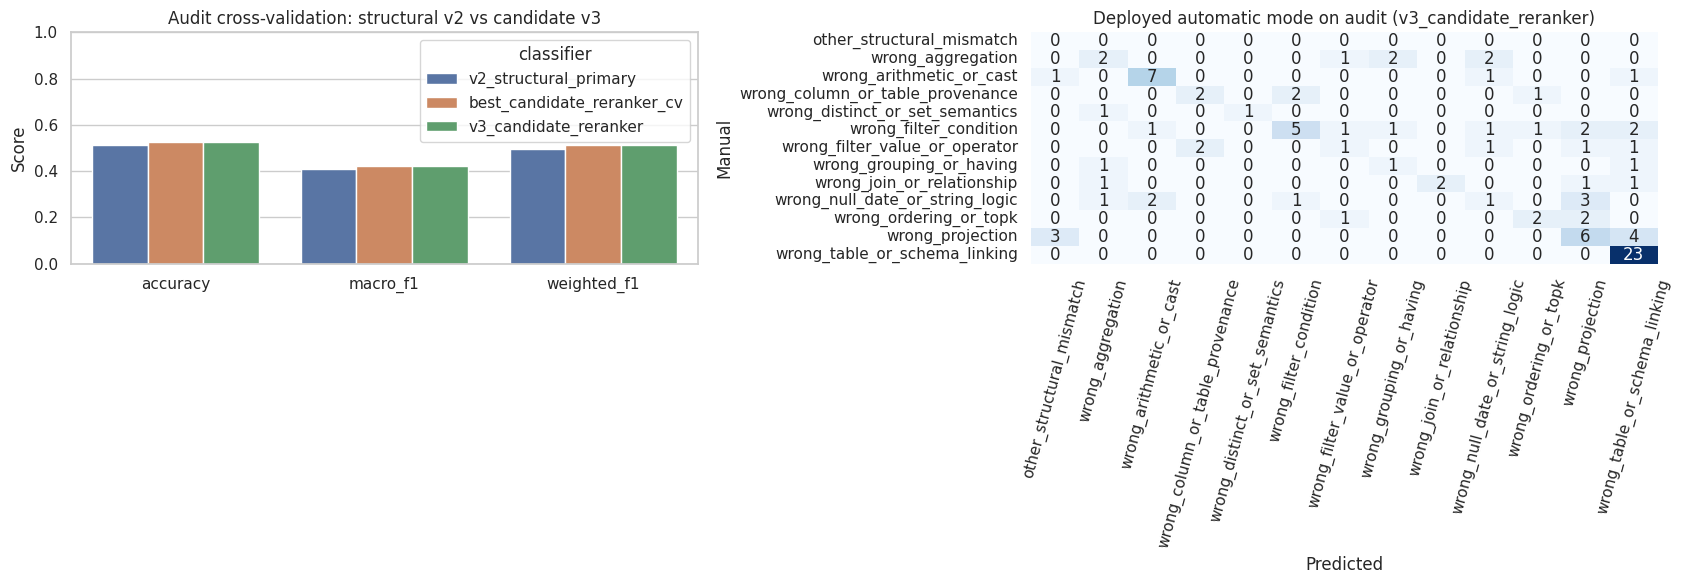

In [14]:
metric_plot = classifier_validation_summary.loc[
    classifier_validation_summary["classifier"].isin([
        "v2_structural_primary", "best_candidate_reranker_cv", deployed_name,
    ])
].drop_duplicates("classifier").melt(
    id_vars="classifier",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=metric_plot, x="metric", y="score", hue="classifier", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Audit cross-validation: structural v2 vs candidate v3")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")

sns.heatmap(
    classifier_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title(f"Deployed automatic mode on audit ({deployed_name})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Manual")
axes[1].tick_params(axis="x", rotation=75)
axes[1].tick_params(axis="y", rotation=0)
plt.tight_layout()

classifier_validation_chart_path = OUTPUT_DIR / "classifier_v3_audit_validation.png"
fig.savefig(classifier_validation_chart_path, dpi=180, bbox_inches="tight")
plt.show()


## 9. Classify all valid-but-wrong Candidate-1 rows and apply Gold-aware overrides


In [15]:
valid_wrong = all_results.loc[
    all_results["analysis_state"].eq("valid_wrong")
].copy().reset_index(drop=True)

print("Valid-but-wrong rows before Gold-aware adjudication:", len(valid_wrong))

v2_rows = [
    classify_sql_pair(row.analysis_predicted_sql, row.gold_sql)
    for row in valid_wrong.itertuples(index=False)
]
v2_classification = pd.DataFrame(v2_rows)
valid_wrong_labeled = pd.concat([valid_wrong, v2_classification], axis=1)
valid_wrong_labeled = valid_wrong_labeled.rename(columns={
    "classification_version": "v2_classification_version",
    "primary_failure_mode": "v2_primary_failure_mode",
    "primary_failure_label": "v2_primary_failure_label",
    "secondary_failure_tags": "v2_secondary_failure_tags",
    "classification_confidence": "v2_classification_confidence",
    "classification_confidence_score": "v2_classification_confidence_score",
    "manual_review_priority": "v2_manual_review_priority",
    "failure_explanation": "v2_failure_explanation",
    "feature_differences_json": "v2_feature_differences_json",
})

valid_wrong_labeled["candidate_modes"] = [
    candidate_mode_set(primary, secondary)
    for primary, secondary in zip(
        valid_wrong_labeled["v2_primary_failure_mode"],
        valid_wrong_labeled["v2_secondary_failure_tags"],
    )
]
candidate_deployment = pd.DataFrame([
    rerank_one(primary, candidates, final_reliability, best_key[1])
    for primary, candidates in zip(
        valid_wrong_labeled["v2_primary_failure_mode"],
        valid_wrong_labeled["candidate_modes"],
    )
], columns=["candidate_reranker_mode", "candidate_reranker_score", "candidate_reranker_margin"])
valid_wrong_labeled = pd.concat([valid_wrong_labeled, candidate_deployment], axis=1)
valid_wrong_labeled["automatic_v3_mode"] = np.where(
    DEPLOY_RERANKER,
    valid_wrong_labeled["candidate_reranker_mode"],
    valid_wrong_labeled["v2_primary_failure_mode"],
)

audit_assignments = audit[[
    "Row", "Experiment", "Position", "Database", "Adjudication status",
    "audited_failure_mode", "Review confidence", "Review notes", "Reviewer",
]].rename(columns={
    "Row": "audit_row",
    "Experiment": "experiment",
    "Position": "position",
    "Database": "db_id",
    "Adjudication status": "adjudication_status",
    "Review confidence": "audit_review_confidence",
    "Review notes": "audit_review_notes",
    "Reviewer": "audit_reviewer",
})

full_keys = valid_wrong_labeled[["experiment", "position", "db_id"]].drop_duplicates()
audit_key_check = audit_assignments.merge(
    full_keys,
    on=["experiment", "position", "db_id"],
    how="left",
    indicator=True,
    validate="one_to_one",
)
missing_audit_keys = audit_key_check.loc[audit_key_check["_merge"].ne("both")]
if not missing_audit_keys.empty:
    display(missing_audit_keys.head(20))
    raise RuntimeError(
        "The adjudication workbook does not match the selected inference CSVs. "
        "Use the exact result directory that produced the audit sample."
    )

valid_wrong_labeled = valid_wrong_labeled.merge(
    audit_assignments,
    on=["experiment", "position", "db_id"],
    how="left",
    validate="one_to_one",
)
valid_wrong_labeled["adjudication_status"] = (
    valid_wrong_labeled["adjudication_status"].fillna("not_audited").astype(str)
)

audited_model_mask = valid_wrong_labeled["adjudication_status"].isin(MODEL_ERROR_STATUSES)
audited_non_model_mask = valid_wrong_labeled["adjudication_status"].isin(NON_MODEL_STATUSES)
pending_mask = valid_wrong_labeled["adjudication_status"].isin(PENDING_STATUSES)
unaudited_mask = valid_wrong_labeled["adjudication_status"].eq("not_audited")

valid_wrong_labeled["gold_aware_scope"] = np.select(
    [audited_model_mask, audited_non_model_mask, pending_mask, unaudited_mask],
    [
        "audited_model_error",
        "audited_non_model_execution_mismatch",
        "pending_adjudication",
        "provisional_unaudited_model_error",
    ],
    default="unexpected_status",
)
valid_wrong_labeled["include_in_failure_mode_summary"] = audited_model_mask | unaudited_mask
valid_wrong_labeled["primary_failure_mode"] = np.select(
    [audited_model_mask, audited_non_model_mask | pending_mask, unaudited_mask],
    [
        valid_wrong_labeled["audited_failure_mode"],
        "",
        valid_wrong_labeled["automatic_v3_mode"],
    ],
    default="",
)
valid_wrong_labeled["classification_source"] = np.select(
    [audited_model_mask, audited_non_model_mask, pending_mask, unaudited_mask],
    [
        "human_final_adjudication",
        "excluded_by_final_adjudication",
        "pending_human_adjudication",
        "candidate_reranker" if DEPLOY_RERANKER else "v2_structural_fallback_safety_gate",
    ],
    default="unexpected_status",
)
valid_wrong_labeled["classification_version"] = CLASSIFIER_V3_VERSION
valid_wrong_labeled["primary_failure_label"] = valid_wrong_labeled["primary_failure_mode"].map(
    FAILURE_LABELS
).fillna("")
valid_wrong_labeled["classification_confidence"] = np.select(
    [audited_model_mask, audited_non_model_mask, pending_mask, unaudited_mask],
    [
        "human_adjudicated", "not_applicable", "pending",
        valid_wrong_labeled["v2_classification_confidence"],
    ],
    default="unknown",
)

if "oracle_at_5" in valid_wrong_labeled.columns:
    oracle5 = bool_series(valid_wrong_labeled["oracle_at_5"])
    valid_wrong_labeled["oracle_diagnosis"] = np.where(
        oracle5,
        "selection_opportunity_correct_candidate_in_top5",
        "generation_gap_no_correct_candidate_in_top5",
    )
else:
    valid_wrong_labeled["oracle_diagnosis"] = "oracle_not_available"

preferred_columns = [
    "experiment", "model_type", "use_evidence", "position", "source_index",
    "db_id", "difficulty", "question", "evidence", "classification_version",
    "adjudication_status", "gold_aware_scope", "include_in_failure_mode_summary",
    "primary_failure_mode", "primary_failure_label", "classification_source",
    "classification_confidence", "automatic_v3_mode", "candidate_reranker_mode",
    "candidate_reranker_score", "candidate_reranker_margin",
    "v2_primary_failure_mode", "v2_secondary_failure_tags",
    "v2_classification_confidence", "v2_failure_explanation",
    "audited_failure_mode", "audit_review_confidence", "audit_review_notes",
    "oracle_diagnosis", "analysis_predicted_sql", "gold_sql",
    "v2_feature_differences_json", "source_result_file",
]
remaining_columns = [
    column for column in valid_wrong_labeled.columns if column not in preferred_columns
]
valid_wrong_labeled = valid_wrong_labeled[preferred_columns + remaining_columns]

known_non_model_cases = valid_wrong_labeled.loc[audited_non_model_mask].copy()
eligible_failure_cases = valid_wrong_labeled.loc[
    valid_wrong_labeled["include_in_failure_mode_summary"]
].copy()

print("Included confirmed/provisional model errors:", len(eligible_failure_cases))
print("Excluded known non-model execution mismatches:", len(known_non_model_cases))
display(valid_wrong_labeled[preferred_columns].head(10))


Valid-but-wrong rows before Gold-aware adjudication: 412
Included confirmed/provisional model errors: 397
Excluded known non-model execution mismatches: 15


,experiment,model_type,use_evidence,position,source_index,db_id,difficulty,question,evidence,classification_version,adjudication_status,gold_aware_scope,include_in_failure_mode_summary,primary_failure_mode,primary_failure_label,classification_source,classification_confidence,automatic_v3_mode,candidate_reranker_mode,candidate_reranker_score,candidate_reranker_margin,v2_primary_failure_mode,v2_secondary_failure_tags,v2_classification_confidence,v2_failure_explanation,audited_failure_mode,audit_review_confidence,audit_review_notes,oracle_diagnosis,analysis_predicted_sql,gold_sql,v2_feature_differences_json,source_result_file
0,baseline_with_evidence,baseline,True,1,1,debit_card_specializing,moderate,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.,3.0-gold-aware,confirmed_model_error,audited_model_error,True,wrong_grouping_or_having,Wrong grouping / HAVING,human_final_adjudication,human_adjudicated,wrong_null_date_or_string_logic,wrong_null_date_or_string_logic,0.346337,0.150221,wrong_null_date_or_string_logic,wrong_filter_value_or_operator|wrong_ordering_or_topk|wrong_grouping_or_having|wrong_aggregation,low,"Wrong NULL / date / string / window logic: {""string_functions"": {""gold"": [""substr""], ""predicted"": []}} || Wrong filter value / operator: {""gold_literals"": [""number:1"", ""number:...",wrong_grouping_or_having,high,Prediction orders individual monthly rows rather than grouping by customer and comparing annual total consumption.,generation_gap_no_correct_candidate_in_top5,SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T2.Date LIKE '2012%' AND T1.Segment = 'LAM' ORDER BY T2.Consumption ...,"SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Segment = 'LAM' AND SUBSTR(T2.Date, 1, 4) = '2012' GROUP BY T1.Cu...","{""aggregation"": {""gold"": {""column_groups"": [""[\""consumption\""]""], ""condition_column_groups"": [""[]""], ""count"": 1, ""details"": [{""columns"": [""consumption""], ""condition_columns"": [...",baseline_with_evidence_minidev500_results.csv
1,baseline_with_evidence,baseline,True,2,2,debit_card_specializing,moderate,What was the average monthly consumption of customers in SME for the year 2013?,Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the yearmonth table can ...,3.0-gold-aware,prediction_semantically_equivalent,audited_non_model_execution_mismatch,False,,,excluded_by_final_adjudication,not_applicable,wrong_null_date_or_string_logic,wrong_null_date_or_string_logic,0.346337,0.128677,wrong_null_date_or_string_logic,wrong_filter_value_or_operator|wrong_join_or_relationship|wrong_filter_condition|wrong_subquery_or_cte,low,"Wrong NULL / date / string / window logic: {""string_functions"": {""gold"": [""substr""], ""predicted"": []}} || Wrong filter value / operator: {""gold_literals"": [""number:1"", ""number:...",,low,BETWEEN/IN and SUBSTR/JOIN appear semantically equivalent here; database inspection is needed to explain the execution mismatch.,selection_opportunity_correct_candidate_in_top5,SELECT AVG(Consumption) / 12 FROM yearmonth WHERE Date BETWEEN '201301' AND '201312' AND CustomerID IN ( SELECT CustomerID FROM customers WHERE Segment = 'SME' ),"SELECT AVG(T2.Consumption) / 12 FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2013' AND T1.Segment = 'SME'","{""filter_condition"": {""gold_columns"": [""date"", ""segment""], ""gold_logic"": [""and""], ""gold_present"": true, ""predicted_columns"": [""customerid"", ""customerid"", ""date"", ""segment""], ""p...",baseline_with_evidence_minidev500_results.csv
2,baseline_with_evidence,baseline,True,3,3,debit_card_specializing,challe

## 10. Gold-aware aggregate statistics


In [16]:
state_summary = (
    all_results.groupby(
        ["experiment", "model_type", "use_evidence", "analysis_state"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "count"})
)
state_totals = all_results.groupby("experiment").size().rename("all_examples")
state_summary = state_summary.join(state_totals, on="experiment")
state_summary["share_of_all_examples"] = state_summary["count"] / state_summary["all_examples"]

audit_failure_mode_summary = (
    model_audit.groupby(
        ["Experiment", "Model", "audited_failure_mode"], as_index=False
    )
    .size()
    .rename(columns={
        "Experiment": "experiment",
        "Model": "model_type",
        "audited_failure_mode": "primary_failure_mode",
        "size": "count",
    })
)
audit_failure_mode_summary["primary_failure_label"] = (
    audit_failure_mode_summary["primary_failure_mode"].map(FAILURE_LABELS)
)

failure_mode_summary = (
    eligible_failure_cases.groupby(
        [
            "experiment", "model_type", "use_evidence",
            "primary_failure_mode", "primary_failure_label",
        ],
        as_index=False,
    )
    .agg(
        count=("position", "size"),
        human_adjudicated_count=("classification_source", lambda s: int((s == "human_final_adjudication").sum())),
        provisional_count=("gold_aware_scope", lambda s: int((s == "provisional_unaudited_model_error").sum())),
        selection_opportunity_count=("oracle_diagnosis", lambda s: int(s.str.startswith("selection_opportunity").sum())),
    )
)
eligible_totals = eligible_failure_cases.groupby("experiment").size().rename("eligible_failure_total")
all_totals = all_results.groupby("experiment").size().rename("all_examples")
failure_mode_summary = failure_mode_summary.join(eligible_totals, on="experiment")
failure_mode_summary = failure_mode_summary.join(all_totals, on="experiment")
failure_mode_summary["share_of_eligible_failures"] = (
    failure_mode_summary["count"] / failure_mode_summary["eligible_failure_total"]
)
failure_mode_summary["share_of_all_examples"] = (
    failure_mode_summary["count"] / failure_mode_summary["all_examples"]
)
failure_mode_summary["human_adjudicated_share"] = (
    failure_mode_summary["human_adjudicated_count"] / failure_mode_summary["count"]
)
failure_mode_summary["selection_opportunity_share"] = (
    failure_mode_summary["selection_opportunity_count"] / failure_mode_summary["count"]
)
failure_mode_summary = failure_mode_summary.sort_values(
    ["experiment", "count"], ascending=[True, False]
).reset_index(drop=True)


def subgroup_summary(group_column):
    result = (
        eligible_failure_cases.groupby(
            [
                "experiment", "model_type", "use_evidence", group_column,
                "primary_failure_mode", "primary_failure_label",
            ],
            dropna=False,
            as_index=False,
        )
        .size()
        .rename(columns={"size": "count"})
    )
    denominator = (
        eligible_failure_cases.groupby(["experiment", group_column], dropna=False)
        .size()
        .rename("eligible_failures_in_group")
    )
    result = result.join(denominator, on=["experiment", group_column])
    result["share_within_group"] = result["count"] / result["eligible_failures_in_group"]
    return result.sort_values(
        ["experiment", group_column, "count"], ascending=[True, True, False]
    )


failure_by_difficulty = subgroup_summary("difficulty")
failure_by_database = subgroup_summary("db_id")

display(state_summary.style.format({"share_of_all_examples": "{:.2%}"}))
display(failure_mode_summary.style.format({
    "share_of_eligible_failures": "{:.2%}",
    "share_of_all_examples": "{:.2%}",
    "human_adjudicated_share": "{:.2%}",
    "selection_opportunity_share": "{:.2%}",
}))


,experiment,model_type,use_evidence,analysis_state,count,all_examples,share_of_all_examples
0,baseline_with_evidence,baseline,True,correct,252,500,50.40%
1,baseline_with_evidence,baseline,True,invalid_sql,53,500,10.60%
2,baseline_with_evidence,baseline,True,valid_wrong,195,500,39.00%
3,sft_with_evidence,sft,True,correct,238,500,47.60%
4,sft_with_evidence,sft,True,invalid_sql,45,500,9.00%
5,sft_with_evidence,sft,True,valid_wrong,217,500,43.40%


,experiment,model_type,use_evidence,primary_failure_mode,primary_failure_label,count,human_adjudicated_count,provisional_count,selection_opportunity_count,eligible_failure_total,all_examples,share_of_eligible_failures,share_of_all_examples,human_adjudicated_share,selection_opportunity_share
0,baseline_with_evidence,baseline,True,wrong_table_or_schema_linking,Wrong table / schema linking,60,10,50,12,184,500,32.61%,12.00%,16.67%,20.00%
1,baseline_with_evidence,baseline,True,wrong_projection,Wrong projection,31,6,25,5,184,500,16.85%,6.20%,19.35%,16.13%
2,baseline_with_evidence,baseline,True,wrong_arithmetic_or_cast,Wrong arithmetic / cast / rounding,27,5,22,6,184,500,14.67%,5.40%,18.52%,22.22%
3,baseline_with_evidence,baseline,True,wrong_null_date_or_string_logic,Wrong NULL / date / string / window logic,19,3,16,3,184,500,10.33%,3.80%,15.79%,15.79%
4,baseline_with_evidence,baseline,True,wrong_filter_condition,Wrong or missing filter condition,18,5,13,6,184,500,9.78%,3.60%,27.78%,33.33%
5,baseline_with_evidence,baseline,True,wrong_filter_value_or_operator,Wrong filter value / operator,13,2,11,1,184,500,7.07%,2.60%,15.38%,7.69%
6,baseline_with_evidence,baseline,True,wrong_aggregation,Wrong aggregation,4,4,0,1,184,500,2.17%,0.80%,100.00%,25.00%
7,baseline_with_evidence,baseline,True,wrong_column_or_table_provenance,Wrong column / table provenance,3,2,1,0,184,500,1.63%,0.60%,66.67%,0.00%
8,baseline_with_evidence,baseline,True,wrong_ordering_or_topk,Wrong ordering / Top-K,3,2,1,0,184,500,1.63%,0.60%,66.67%,0.00%
9,baseline_with_evidence,baseline,True,wrong_distinct_or_set_semantics,Wrong DISTINCT / set semantics,2,2,0,1,184,500,1.09%,0.40%,100.00%,50.00%


## 11. Paired Base + Evidence → SFT + Evidence changes


In [17]:
def failure_lookup_for(experiment):
    columns = [
        "position", "db_id", "primary_failure_mode",
        "classification_confidence", "gold_aware_scope", "adjudication_status",
    ]
    return valid_wrong_labeled.loc[
        valid_wrong_labeled["experiment"].eq(experiment), columns
    ].copy()


BASE_EXPERIMENT = "baseline_with_evidence"
SFT_EXPERIMENT = "sft_with_evidence"
common = ["position", "db_id"]
context_columns = ["source_index", "difficulty", "question", "evidence", "gold_sql"]
metric_columns = [
    "analysis_state", "analysis_valid_sql", "analysis_execution_match",
    "analysis_predicted_sql", "oracle_at_3", "oracle_at_5",
]

base = all_results.loc[
    all_results["experiment"].eq(BASE_EXPERIMENT),
    common + context_columns + [column for column in metric_columns if column in all_results.columns],
].copy()
sft = all_results.loc[
    all_results["experiment"].eq(SFT_EXPERIMENT),
    common + [column for column in metric_columns if column in all_results.columns],
].copy()

base_failure = failure_lookup_for(BASE_EXPERIMENT).rename(columns={
    "primary_failure_mode": "baseline_failure_mode",
    "classification_confidence": "baseline_failure_confidence",
    "gold_aware_scope": "baseline_gold_aware_scope",
    "adjudication_status": "baseline_adjudication_status",
})
sft_failure = failure_lookup_for(SFT_EXPERIMENT).rename(columns={
    "primary_failure_mode": "sft_failure_mode",
    "classification_confidence": "sft_failure_confidence",
    "gold_aware_scope": "sft_gold_aware_scope",
    "adjudication_status": "sft_adjudication_status",
})

base = base.merge(base_failure, on=common, how="left", validate="one_to_one")
sft = sft.merge(sft_failure, on=common, how="left", validate="one_to_one")
paired_base_sft = base.merge(
    sft,
    on=common,
    how="inner",
    validate="one_to_one",
    suffixes=("_baseline", "_sft"),
)
paired_base_sft["use_evidence"] = True
paired_base_sft["pair_condition"] = "with_evidence"
paired_base_sft["state_transition"] = (
    paired_base_sft["analysis_state_baseline"]
    + " -> "
    + paired_base_sft["analysis_state_sft"]
)
paired_base_sft["model_effect"] = np.select(
    [
        ~paired_base_sft["analysis_execution_match_baseline"] & paired_base_sft["analysis_execution_match_sft"],
        paired_base_sft["analysis_execution_match_baseline"] & ~paired_base_sft["analysis_execution_match_sft"],
        paired_base_sft["analysis_execution_match_baseline"] & paired_base_sft["analysis_execution_match_sft"],
        paired_base_sft["analysis_state_baseline"].eq("valid_wrong")
        & paired_base_sft["analysis_state_sft"].eq("valid_wrong"),
    ],
    ["improved_to_correct", "regressed_from_correct", "both_correct", "both_valid_wrong"],
    default="other_noncorrect_transition",
)

model_effect_summary = (
    paired_base_sft.groupby(["pair_condition", "model_effect"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
pair_totals = paired_base_sft.groupby("pair_condition").size().rename("pair_total")
model_effect_summary = model_effect_summary.join(pair_totals, on="pair_condition")
model_effect_summary["share"] = model_effect_summary["count"] / model_effect_summary["pair_total"]

state_transition_summary = (
    paired_base_sft.groupby(["pair_condition", "state_transition"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

both_valid_wrong = paired_base_sft.loc[
    paired_base_sft["model_effect"].eq("both_valid_wrong")
].copy()
failure_transition_summary = (
    both_valid_wrong.groupby(
        [
            "pair_condition", "baseline_failure_mode", "sft_failure_mode",
            "baseline_gold_aware_scope", "sft_gold_aware_scope",
        ],
        dropna=False,
        as_index=False,
    )
    .size()
    .rename(columns={"size": "count"})
    .sort_values(["pair_condition", "count"], ascending=[True, False])
)

sft_improvements = paired_base_sft.loc[
    paired_base_sft["model_effect"].eq("improved_to_correct")
].copy()
sft_regressions = paired_base_sft.loc[
    paired_base_sft["model_effect"].eq("regressed_from_correct")
].copy()

display(model_effect_summary.style.format({"share": "{:.2%}"}))
display(failure_transition_summary.head(30))


,pair_condition,model_effect,count,pair_total,share
0,with_evidence,both_correct,205,500,41.00%
1,with_evidence,both_valid_wrong,154,500,30.80%
2,with_evidence,improved_to_correct,33,500,6.60%
3,with_evidence,other_noncorrect_transition,61,500,12.20%
4,with_evidence,regressed_from_correct,47,500,9.40%


,pair_condition,baseline_failure_mode,sft_failure_mode,baseline_gold_aware_scope,sft_gold_aware_scope,count
58,with_evidence,wrong_table_or_schema_linking,wrong_table_or_schema_linking,provisional_unaudited_model_error,provisional_unaudited_model_error,28
49,with_evidence,wrong_projection,wrong_projection,provisional_unaudited_model_error,provisional_unaudited_model_error,16
9,with_evidence,wrong_arithmetic_or_cast,wrong_arithmetic_or_cast,provisional_unaudited_model_error,provisional_unaudited_model_error,10
21,with_evidence,wrong_filter_condition,wrong_filter_condition,provisional_unaudited_model_error,provisional_unaudited_model_error,10
28,with_evidence,wrong_filter_value_or_operator,wrong_filter_value_or_operator,provisional_unaudited_model_error,provisional_unaudited_model_error,7
40,with_evidence,wrong_null_date_or_string_logic,wrong_null_date_or_string_logic,provisional_unaudited_model_error,provisional_unaudited_model_error,7
57,with_evidence,wrong_table_or_schema_linking,wrong_table_or_schema_linking,provisional_unaudited_model_error,audited_model_error,4
15,with_evidence,wrong_arithmetic_or_cast,wrong_table_or_schema_linking,provisional_unaudited_model_error,provisional_unaudited_model_error,3
47,with_evidence,wrong_projection,wrong_projection,audited_model_error,audited_model_error,3
55,with_evidence,wrong_table_or_schema_linking,wrong_table_or_schema_linking,audited_model_error,audited_model_error,3


## 12. Gold-aware result visualizations


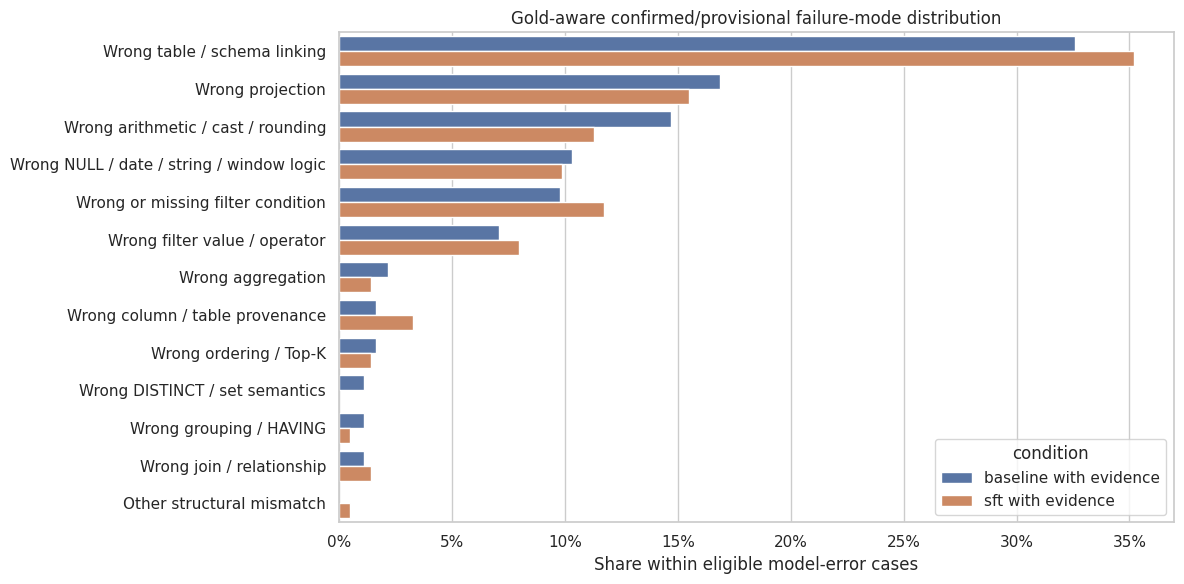

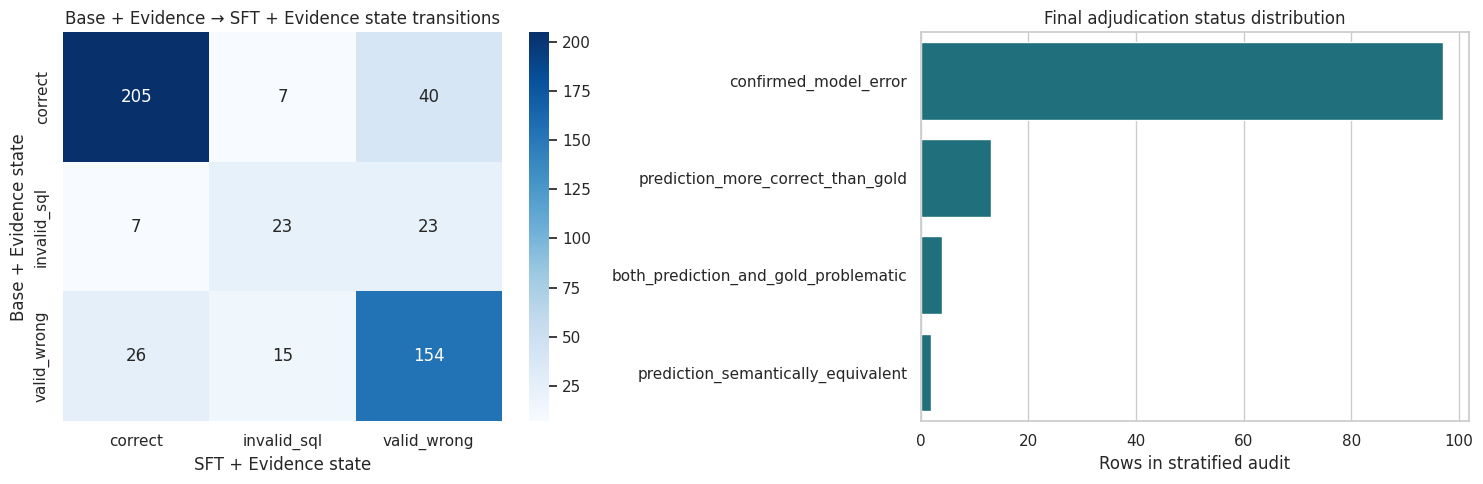

Saved: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_failure_mode_analysis_with_evidence_v3/failure_mode_distribution_v3_gold_aware.png
Saved: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_failure_mode_analysis_with_evidence_v3/base_to_sft_state_and_adjudication.png
Saved: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_failure_mode_analysis_with_evidence_v3/classifier_v3_audit_validation.png


In [18]:
plot_data = failure_mode_summary.copy()
plot_data["condition"] = plot_data["experiment"].str.replace("_", " ")

fig_height = max(6, 0.45 * plot_data["primary_failure_label"].nunique())
fig, ax = plt.subplots(figsize=(12, fig_height))
sns.barplot(
    data=plot_data,
    y="primary_failure_label",
    x="share_of_eligible_failures",
    hue="condition",
    ax=ax,
)
ax.set_title("Gold-aware confirmed/provisional failure-mode distribution")
ax.set_xlabel("Share within eligible model-error cases")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
failure_chart_path = OUTPUT_DIR / "failure_mode_distribution_v3_gold_aware.png"
fig.savefig(failure_chart_path, dpi=180, bbox_inches="tight")
plt.show()

matrix = pd.crosstab(
    paired_base_sft["analysis_state_baseline"],
    paired_base_sft["analysis_state_sft"],
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Base + Evidence → SFT + Evidence state transitions")
axes[0].set_xlabel("SFT + Evidence state")
axes[0].set_ylabel("Base + Evidence state")

sns.barplot(
    data=adjudication_status_summary,
    y="Adjudication status",
    x="count",
    color="#0F7C8C",
    ax=axes[1],
)
axes[1].set_title("Final adjudication status distribution")
axes[1].set_xlabel("Rows in stratified audit")
axes[1].set_ylabel("")
plt.tight_layout()
transition_chart_path = OUTPUT_DIR / "base_to_sft_state_and_adjudication.png"
fig.savefig(transition_chart_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", failure_chart_path)
print("Saved:", transition_chart_path)
print("Saved:", classifier_validation_chart_path)


## 13. Save all v3 analysis artifacts


In [19]:
def atomic_write_csv(df, path, index=False):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(temporary, index=index)
    os.replace(temporary, path)


def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(type(value).__name__)


def atomic_write_json(payload, path):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, default=json_default),
        encoding="utf-8",
    )
    os.replace(temporary, path)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


OUTPUTS = {
    "valid_wrong_labeled_v3": OUTPUT_DIR / "valid_wrong_labeled_cases_v3.csv",
    "known_non_model_cases": OUTPUT_DIR / "known_non_model_execution_mismatches.csv",
    "adjudication_normalized": OUTPUT_DIR / "final_adjudication_normalized.csv",
    "adjudication_status_summary": OUTPUT_DIR / "adjudication_status_summary.csv",
    "audit_failure_mode_summary": OUTPUT_DIR / "audited_failure_mode_summary.csv",
    "classifier_validation_rows": OUTPUT_DIR / "classifier_v3_validation_rows.csv",
    "classifier_validation_summary": OUTPUT_DIR / "classifier_v3_validation_summary.csv",
    "classifier_per_class": OUTPUT_DIR / "classifier_v3_per_class_metrics.csv",
    "classifier_confusion_matrix": OUTPUT_DIR / "classifier_v3_confusion_matrix.csv",
    "calibration_grid": OUTPUT_DIR / "classifier_v3_calibration_grid.csv",
    "state_summary": OUTPUT_DIR / "result_state_summary.csv",
    "failure_mode_summary": OUTPUT_DIR / "failure_mode_summary_v3.csv",
    "failure_by_difficulty": OUTPUT_DIR / "failure_mode_by_difficulty_v3.csv",
    "failure_by_database": OUTPUT_DIR / "failure_mode_by_database_v3.csv",
    "paired_base_sft": OUTPUT_DIR / "paired_base_sft_cases_v3.csv",
    "model_effect_summary": OUTPUT_DIR / "base_vs_sft_model_effect_summary.csv",
    "state_transition_summary": OUTPUT_DIR / "base_to_sft_state_transition_summary.csv",
    "failure_transition_summary": OUTPUT_DIR / "base_to_sft_failure_mode_transitions_v3.csv",
    "sft_improvements": OUTPUT_DIR / "sft_improvements.csv",
    "sft_regressions": OUTPUT_DIR / "sft_regressions.csv",
}

validation_columns = [
    "Row", "Experiment", "Position", "Database", "Question",
    "Adjudication status", "manual_failure_mode",
    "recomputed_primary_failure_mode", "recomputed_secondary_failure_tags",
    "candidate_contains_manual", "candidate_reranker_cv_prediction",
    "deployed_cv_prediction", "deployed_cv_correct",
]
DATAFRAMES = {
    "valid_wrong_labeled_v3": valid_wrong_labeled,
    "known_non_model_cases": known_non_model_cases,
    "adjudication_normalized": audit,
    "adjudication_status_summary": adjudication_status_summary,
    "audit_failure_mode_summary": audit_failure_mode_summary,
    "classifier_validation_rows": model_audit[validation_columns],
    "classifier_validation_summary": classifier_validation_summary,
    "classifier_per_class": per_class,
    "classifier_confusion_matrix": classifier_confusion_matrix,
    "calibration_grid": calibration_grid,
    "state_summary": state_summary,
    "failure_mode_summary": failure_mode_summary,
    "failure_by_difficulty": failure_by_difficulty,
    "failure_by_database": failure_by_database,
    "paired_base_sft": paired_base_sft,
    "model_effect_summary": model_effect_summary,
    "state_transition_summary": state_transition_summary,
    "failure_transition_summary": failure_transition_summary,
    "sft_improvements": sft_improvements,
    "sft_regressions": sft_regressions,
}
for name, dataframe in DATAFRAMES.items():
    atomic_write_csv(
        dataframe,
        OUTPUTS[name],
        index=(name == "classifier_confusion_matrix"),
    )

top_modes = (
    failure_mode_summary.sort_values(["experiment", "count"], ascending=[True, False])
    .groupby("experiment", as_index=False)
    .head(5)
)
calibration_payload = {
    "classifier_version": CLASSIFIER_V3_VERSION,
    "v2_structural_version": CLASSIFIER_VERSION,
    "deploy_reranker": DEPLOY_RERANKER,
    "deployment_name": deployed_name,
    "selected_alpha": best_key[0],
    "selected_primary_bonus": best_key[1],
    "minimum_deploy_gain": MIN_DEPLOY_GAIN,
    "trigger_reliability": final_reliability,
    "validation": {
        "v2": v2_metrics,
        "candidate": candidate_metrics,
        "deployed": deployed_metrics,
        "accuracy_delta": accuracy_delta,
        "macro_f1_delta": macro_f1_delta,
        "candidate_recall": float(model_audit["candidate_contains_manual"].mean()),
    },
}
calibration_json_path = OUTPUT_DIR / "failure_classifier_v3_calibration.json"
atomic_write_json(calibration_payload, calibration_json_path)

analysis_summary = {
    "analysis_definition": {
        "candidate_rank": CANDIDATE_RANK,
        "conditions": ["baseline_with_evidence", "sft_with_evidence"],
        "classifier_version": CLASSIFIER_V3_VERSION,
        "structural_engine": f"sqlglot AST-difference rules v{CLASSIFIER_VERSION}",
        "gold_aware_rule": (
            "Audited model errors receive final human modes; audited semantic-equivalent, "
            "prediction-better-than-Gold, and ambiguous rows are excluded; unaudited rows are provisional."
        ),
        "audit_warning": "The stratified audit is not a population-random accuracy sample.",
    },
    "input": {
        "selected_results_directory": str(SELECTED_RESULTS_DIR),
        "result_files": [str(path) for path in RESULT_FILES],
        "adjudication_file": str(ADJUDICATION_FILE),
        "adjudication_sha256": sha256_file(ADJUDICATION_FILE),
        "result_sha256": {path.name: sha256_file(path) for path in RESULT_FILES},
        "total_result_rows": int(len(all_results)),
        "audit_rows": int(len(audit)),
    },
    "audit_counts": {
        "model_error_rows": int(audit["include_as_model_error"].sum()),
        "known_non_model_rows": int(audit["Adjudication status"].isin(NON_MODEL_STATUSES).sum()),
        "pending_rows": int(audit["Adjudication status"].isin(PENDING_STATUSES).sum()),
    },
    "deployment": calibration_payload,
    "full_analysis_counts": {
        "raw_valid_wrong_rows": int(len(valid_wrong_labeled)),
        "eligible_confirmed_or_provisional_failure_rows": int(len(eligible_failure_cases)),
        "known_non_model_rows_excluded": int(len(known_non_model_cases)),
        "sft_improvements": int(len(sft_improvements)),
        "sft_regressions": int(len(sft_regressions)),
    },
    "top_failure_modes_by_condition": top_modes[
        ["experiment", "primary_failure_mode", "count", "share_of_eligible_failures"]
    ].to_dict(orient="records"),
    "taxonomy": FAILURE_LABELS,
    "software_versions": {
        "python": os.sys.version,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "sqlglot": sqlglot.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "outputs": {name: str(path) for name, path in OUTPUTS.items()},
}
summary_json_path = OUTPUT_DIR / "failure_mode_analysis_summary_v3.json"
atomic_write_json(analysis_summary, summary_json_path)

print("Failure-mode analysis v3 complete. Files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f" - {path.name} ({path.stat().st_size / 1024:.1f} KB)")


Failure-mode analysis v3 complete. Files:
 - adjudication_status_summary.csv (0.3 KB)
 - audited_failure_mode_summary.csv (1.9 KB)
 - base_to_sft_failure_mode_transitions_v3.csv (7.3 KB)
 - base_to_sft_state_and_adjudication.png (122.3 KB)
 - base_to_sft_state_transition_summary.csv (0.4 KB)
 - base_vs_sft_model_effect_summary.csv (0.3 KB)
 - classifier_v3_audit_validation.png (408.8 KB)
 - classifier_v3_calibration_grid.csv (3.9 KB)
 - classifier_v3_confusion_matrix.csv (1.0 KB)
 - classifier_v3_per_class_metrics.csv (1.2 KB)
 - classifier_v3_validation_rows.csv (34.7 KB)
 - classifier_v3_validation_summary.csv (0.4 KB)
 - failure_classifier_v3_calibration.json (1.9 KB)
 - failure_mode_analysis_summary_v3.json (10.1 KB)
 - failure_mode_by_database_v3.csv (16.3 KB)
 - failure_mode_by_difficulty_v3.csv (6.4 KB)
 - failure_mode_distribution_v3_gold_aware.png (160.9 KB)
 - failure_mode_summary_v3.csv (3.9 KB)
 - final_adjudication_normalized.csv (141.5 KB)
 - known_non_model_execution_mis

## 14. How to interpret the v3 outputs

Recommended reading order:

1. `classifier_v3_validation_summary.csv`: compare v2, the cross-validated candidate reranker, and the automatically deployed option.
2. `adjudication_status_summary.csv`: quantify confirmed model errors versus known benchmark/reference issues.
3. `known_non_model_execution_mismatches.csv`: keep these rows out of failure-mode training and model-error counts.
4. `failure_mode_summary_v3.csv`: compare Base + Evidence and SFT + Evidence after known non-model rows are excluded.
5. `valid_wrong_labeled_cases_v3.csv`: row-level provenance, including whether the label came from human adjudication or a provisional automatic rule.
6. `sft_regressions.csv`: prioritize cases that Base solved but SFT broke.
7. `base_to_sft_failure_mode_transitions_v3.csv`: inspect whether SFT removes a failure or changes its form.

Do not present provisional unaudited labels as ground truth. For targeted SFT/DPO data construction, prioritize high-frequency **audited** modes and retain the `classification_source` and `gold_aware_scope` columns in every downstream dataset.
